<div style="text-align: center; padding-top: 12%;">

# Classification

## DATA 301 @ WM

<figure class="no-fragment">
<center>
<a href="https://github.com/yanhai-xiong/DATA301-AML/blob/main/Module%203%20-%20Supervised%20Learning%20-%20Regression%20and%20Classification%20Problems/Section%202.1%20-%20Classification%20Problems.ipynb" target="_blank">
    <img class="no-fragment"
         src="https://brand.github.com/_next/static/media/logo-03.cc5e5332.png"
         width="80px"/>
</a>
</center>
</figure>
</div>

> How can we predict a class/probability instead of a continuous value?

# <font color='blue' size=8pt> Classification Algorithms</font>

**Critical Thinking**: <font color='red'> What is *classification*?</font> 
What is the difference between <font color='deepskyblue'>*regression*</font> and <font color='forestgreen'>*classification*?</font>

**Regression**: the dependent variable is continuous and we want to predict the expected value given the input features.

**Classification**:
the target variable is categorical, and the goal is to predict a class label and/or the probability of each class.

## Motivating Example

With only **one continuous input feature**, we can visualize how the
classes are separated.

<font color='magenta'>**Example**</font> Suppose we have weight measurements
for two types of animals. Can **weight alone** help us predict which type
an animal belongs to?

**Question:** Where would you place a decision boundary to separate the two classes?

<table><tr>
<td>
    <img src="https://i.imgur.com/JpGUIaO.png" alt="Image 1"
    width='700px'> </td>
   <td>  
   <img src="https://i.imgur.com/Pg4FBdj.png" alt="Image 2" width='710px'> </td>
</tr></table>

## <font color='blue'> Logistic Regression </font>

### <font color='blue'>From Linear Regression to Classification</font>

Suppose we want to predict whether an animal is a **rabbit** ($y=1$) or a **squirrel** ($y=0$) based on its weight $x$.

Instead of directly predicting the class, **logistic regression predicts the probability of belonging to class 1**:
$$
p(x)=P(y=1\mid x)
$$

A linear model is not ideal for modeling this probability because
$$
\beta_0+\beta_1x
$$
can take **any value from $-\infty$ to $+\infty$**, while a probability must satisfy
$$
0\leq P(y=1\mid x)\leq 1.
$$

### <font color='blue'>The Sigmoid Function</font>

Logistic regression solves this problem by transforming the linear model using the **sigmoid (logistic) function**:
$$
\large
P(y=1\mid x)
=
\frac{1}{1+e^{-(\beta_0+\beta_1x)}}.
$$

The sigmoid maps any real-valued input into a value between 0 and 1:
$$
-\infty < \beta_0+\beta_1x < \infty
\quad\Longrightarrow\quad
0<P(y=1\mid x)<1.
$$

For our example,
$$
P(\text{rabbit}\mid \text{weight}=x)
=
\frac{1}{1+e^{-(\beta_0+\beta_1x)}}.
$$

Because there are only two classes,
$$
P(\text{rabbit}\mid x)+P(\text{squirrel}\mid x)=1.
$$

### <font color='blue'>Why Is It Called Logistic *Regression*?</font>

Define the **odds** of belonging to class 1 as
$$
\text{odds}
=
\frac{P(y=1\mid x)}{P(y=0\mid x)}
=
\frac{p(x)}{1-p(x)}.
$$

The odds range from $0$ to $\infty$. Taking the logarithm gives the **log-odds (logit)**:
$$
\log\left(\frac{p(x)}{1-p(x)}\right).
$$

Logistic regression assumes that the **log-odds are a linear function of the input features**:
$$
\log\left(\frac{p(x)}{1-p(x)}\right)
=
\beta_0+\beta_1x.
$$

With multiple features,
$$
\log\left(\frac{p(\mathbf{x})}{1-p(\mathbf{x})}\right)
=
\beta_0+\beta_1x_1+\cdots+\beta_px_p.
$$

#### <font color='blue'> Self-Study: Why Model the Log-Odds? </font>

Why don't we model the probability $p(x)$ directly as a linear function of the features?

Consider the ranges:

$$
\begin{aligned}
\text{Probability:}\quad
&p(x) &&\in (0,1) \\[4pt]
\text{Odds:}\quad
&\frac{p(x)}{1-p(x)} &&\in (0,\infty) \\[4pt]
\text{Log-odds:}\quad
&\log\left(\frac{p(x)}{1-p(x)}\right) &&\in (-\infty,\infty)
\end{aligned}
$$

The **log-odds can take any real value**, just like a linear function:

$$
\beta_0+\beta_1x \in (-\infty,\infty).
$$

This motivates the key assumption of logistic regression:

$$
\boxed{
\log\left(\frac{p(x)}{1-p(x)}\right)
=
\beta_0+\beta_1x
}
$$

In other words:

> **Logistic regression assumes that the log-odds of belonging to class 1 change linearly with the input features.**

Solving this equation for $p(x)$ gives

$$
p(x)
=
\frac{1}{1+e^{-(\beta_0+\beta_1x)}},
$$

which is the familiar **sigmoid curve**.

So we can think of logistic regression as:

$$
\boxed{
\text{Features}
\rightarrow
\text{Linear Score}
\rightarrow
\text{Log-Odds}
\rightarrow
\text{Probability}
}
$$

### <font color='blue'>From Probability to Classification</font>

Logistic regression first predicts a **probability**. We then choose a threshold to convert that probability into a class.

For example, using a threshold of $0.5$:
$$
\hat y =
\begin{cases}
1, & P(y=1\mid \mathbf{x})\geq 0.5,\\
0, & P(y=1\mid \mathbf{x})<0.5.
\end{cases}
$$

> **Logistic regression predicts a probability; a decision threshold converts that probability into a class.**

## <font color="blue"> Training Logistic Regression: An Intuitive Animation </font>

Just like linear regression, logistic regression **learns the model parameters** by minimizing a loss function. 
For each observation, the model first predicts
$$
p_i=P(y_i=1\mid x_i)
=
\frac{1}{1+e^{-(\beta_0+\boldsymbol{\beta}^T\mathbf{x}_i)}}.
$$

But instead of using **Mean Squared Error (MSE)**, logistic regression typically minimizes **Binary Cross-Entropy (Log Loss)**:
$$
\arg\min_{\beta_0,\boldsymbol{\beta}}
\mathcal{L}(\beta_0,\boldsymbol{\beta})
=
-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right].
$$


Gradient descent can update the parameters iteratively:
$$
\boldsymbol{\beta}
\leftarrow
\boldsymbol{\beta}
-
\eta\nabla_{\boldsymbol{\beta}}\mathcal{L}.
$$

As the parameters change, the **sigmoid curve moves**, changing the predicted probabilities and reducing the classification loss.

> **Same idea as before:** predict $\rightarrow$ compute loss $\rightarrow$ compute gradient $\rightarrow$ update parameters $\rightarrow$ repeat.

### Illustration
<figure  class = "no-fragment">
<center>
<img src='https://i.imgur.com/1chWws4.gif'
width='800px' />
<figcaption>Learning the logistic regression model by iteratively updating its parameters</figcaption>
</center>
</figure>

#### <font color="blue"> Self-Study: Binary Cross-Entropy (Log Loss) </font>

For binary classification, the true label is

$$
y_i\in\{0,1\},
$$

and logistic regression predicts a probability

$$
p_i=P(y_i=1\mid \mathbf{x}_i).
$$

We want a loss function that gives a **small penalty for a confident correct prediction** and a **large penalty for a confident wrong prediction**.

For one observation, the **Binary Cross-Entropy (BCE)** loss is

$$
\large
\ell_i
=
-\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right].
$$

---

Case 1: The true class is $y_i=1$

Substituting $y_i=1$,

$$
\ell_i=-\log(p_i).
$$

Therefore:

- $p_i\rightarrow1$ $\Rightarrow$ loss $\rightarrow0$ ✓
- $p_i\rightarrow0$ $\Rightarrow$ loss $\rightarrow\infty$ ✗

The model is strongly penalized if it is **confidently wrong**.

---

Case 2: The true class is $y_i=0$

Substituting $y_i=0$,

$$
\ell_i=-\log(1-p_i).
$$

Therefore:

- $p_i\rightarrow0$ $\Rightarrow$ loss $\rightarrow0$ ✓
- $p_i\rightarrow1$ $\Rightarrow$ loss $\rightarrow\infty$ ✗

Again, confident incorrect predictions receive a large penalty.

For example:

| True label $y_i$ | Predicted $p_i$ | BCE Loss | Interpretation |
|---|---:|---:|---|
| 1 | 0.99 | 0.010 | Confident and correct |
| 1 | 0.60 | 0.511 | Correct, but uncertain |
| 1 | 0.10 | 2.303 | Confident and wrong |
| 0 | 0.01 | 0.010 | Confident and correct |
| 0 | 0.90 | 2.303 | Confident and wrong |

Finally, we average the loss over all $n$ observations:

$$
\boxed{
\mathcal{L}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
}
$$

> **Key idea:** BCE does not simply ask whether the predicted class is correct. It also considers **how confident the predicted probability is**.
---

**Why this particular loss?**

Binary cross-entropy is not an arbitrary choice. If we model

$$
y_i\sim\text{Bernoulli}(p_i),
$$

then minimizing binary cross-entropy is equivalent to **maximizing the likelihood of the observed class labels**.

This connection between **Maximum Likelihood Estimation (MLE)** and log loss is one reason BCE is the natural loss function for logistic regression.

## <font color='blue'>  Multiple Classes </font>

Logistic regression is a fundamental method in statistical modeling used for **binary** classification problems. It estimates the probability that a given input belongs to a certain category. However, many real-world problems require classification into more than two categories, leading to the need for logistic regression models that can handle multiple classes, in which case we estimate probability values for each class and harden the classification based on the highest probability.


### <font color='blue'> Logistic Regression for Multiple Classes </font>

When dealing with multiple classes, logistic regression extends to what is known as **multinomial logistic regression** or **softmax regression**. Here's a brief overview:

**Multinomial Logistic Regression**:
- **Goal**: Classify observations into one of $K$ possible classes.
- **Approach**: Use the softmax function to predict the probabilities of each class.
- **Softmax Function**: The softmax function is an extension of the logistic function. It converts raw scores (logits) from the linear model into probabilities that sum to one.
   
Given an input $ \mathbf{x} $ and weights $ \mathbf{W} $, the probability of class $ k $ is given by:
$$
P(y = k \mid \mathbf{x}) = \frac{e^{b_k+\mathbf{w}_k^\top \mathbf{x}}}{\sum_{j=1}^{K} e^{b_j+\mathbf{w}_j^\top \mathbf{x}}}
$$
where $ \mathbf{w}_k $ is the weight vector for class $ k $.

### <font color='blue'> Distribution as Prediction </font>

For **binary classification**, logistic regression predicts one probability:
$$
p_i=P(y_i=1\mid \mathbf{x}_i).
$$

For **multi-class classification**, we have $K$ possible classes. The model uses **softmax** to predict a probability for each class:
$$
\hat{\mathbf{y}}_i
=
[\hat y_{i,1},\hat y_{i,2},\ldots,\hat y_{i,K}],
$$

where
$$
0\leq \hat y_{i,k}\leq1,
\qquad
\sum_{k=1}^{K}\hat y_{i,k}=1.
$$

Thus, $\hat{\mathbf{y}}_i$ represents the model's **predicted probability distribution over the $K$ classes**.

#### <font color='blue'>Multi-Class Cross-Entropy - True Label vs. Predicted Probabilities</font>

Suppose there are three classes: **Rabbit, Squirrel, and Cat**.

For an observation whose true class is **Rabbit**, the one-hot encoded true label might be $ \mathbf{y}_i=[1,0,0],$
while the model predicts $\hat{\mathbf{y}}_i=[0.8,0.1,0.1]. $

We compare these using **multi-class cross-entropy**:
$$
L_i
=
-\sum_{k=1}^{K}
y_{i,k}\log(\hat y_{i,k}).
$$

Because the true label is one-hot encoded, **only the term corresponding to the correct class remains**:
$$
L_i=-\log(0.8).
$$

More generally, if the true class is $c$,
$$
\boxed{L_i=-\log(\hat y_{i,c})}.
$$
- **High probability for the correct class** $\rightarrow$ small loss
- **Low probability for the correct class** $\rightarrow$ large loss

#### <font color='blue'>Loss over the Dataset</font>

For $N$ observations and $K$ classes, the average cross-entropy loss is

$$
\boxed{
L
=
-\frac{1}{N}
\sum_{i=1}^{N}
\sum_{k=1}^{K}
y_{i,k}\log(\hat y_{i,k})
}
$$

Training adjusts the model parameters to **minimize this loss**, encouraging the model to assign higher probabilities to the correct classes.

> **Key idea:** Cross-entropy asks, *“How much probability did the model assign to the true class?”*

$$
\boxed{
\text{Logit Scores}
\rightarrow
\text{Softmax}
\rightarrow
\text{Class Probabilities}
\rightarrow
\text{Cross-Entropy Loss}
}
$$

**Connection to MLE:** Minimizing multi-class cross-entropy is equivalent to maximizing the likelihood of the observed class labels under the multinomial/categorical model.


### <font color='blue'> Messages </font>

- **Multinomial Logistic Regression**: Extends logistic regression to handle multiple classes using the softmax function.
- **Multi-class Crossentropy**: A loss function used to evaluate the performance of a multi-class classification model by measuring the difference between predicted probabilities and actual labels.

By understanding these concepts, you can effectively apply logistic regression to multi-class classification problems and evaluate the performance of your models using the cross-entropy loss.

### <font color='blue'> Self-Study: What Is Entropy? </font>

**Entropy** measures the **uncertainty** or **impurity** of a probability distribution.

For a random variable with $K$ possible outcomes having probabilities

$$
p_1,p_2,\ldots,p_K,
\qquad
\sum_{k=1}^{K}p_k=1,
$$

the entropy is

$$
\boxed{
H(p)
=
-\sum_{k=1}^{K}p_k\log(p_k)
}
$$

---

#### <font color='blue'>Intuition: How Uncertain Are We?</font>

Consider a binary classification problem.

**Case 1: Very certain**

$$
P(\text{Rabbit})=1,\qquad P(\text{Squirrel})=0
$$

There is no uncertainty about the class:

$$
H=0.
$$

**Case 2: Very uncertain**

$$
P(\text{Rabbit})=0.5,\qquad P(\text{Squirrel})=0.5
$$

We are maximally uncertain about the class. Therefore, entropy is at its **maximum**.

For binary classification,

$$
H(p)
=
-p\log(p)-(1-p)\log(1-p).
$$

Thus,

$$
\boxed{
\text{More certain distribution}
\Rightarrow
\text{lower entropy}
}
$$

$$
\boxed{
\text{More evenly distributed probabilities}
\Rightarrow
\text{higher entropy}
}
$$

---

#### <font color='blue'>Why the $\log$?</font>

The quantity

$$
-\log(p)
$$

can be interpreted as the **information** or **surprise** associated with observing an event having probability $p$.

- A very likely event $\rightarrow$ little surprise
- A very unlikely event $\rightarrow$ large surprise

Entropy is the **expected amount of surprise**:

$$
H(p)
=
\sum_{k=1}^{K}
p_k[-\log(p_k)].
$$

---

#### <font color='blue'>Entropy vs. Cross-Entropy</font>

Entropy describes the uncertainty **within one probability distribution**:

$$
H(p)=-\sum_k p_k\log(p_k).
$$

Cross-entropy compares a true distribution $p$ with another distribution $q$:

$$
H(p,q)
=
-\sum_k p_k\log(q_k).
$$

In classification:

- $p$ represents the **true labels**
- $q$ represents the **model's predicted probabilities**

This is why cross-entropy can be used as a loss function: it becomes large when the model assigns a **low probability to the true class**.

> **Key idea:**  
> **Entropy = How uncertain is the distribution?**  
> **Cross-entropy = How well does one distribution represent another?**

---

#### <font color='blue'>Coming Up: Decision Trees</font>

Entropy will appear again in **Decision Trees**.

A node containing mostly one class has **low entropy**, while a node containing a mixture of classes has **high entropy**. A decision tree can therefore search for splits that **reduce entropy**.

$$
\boxed{
\text{Good Split}
\quad\Rightarrow\quad
\text{Lower Class Uncertainty}
}
$$

### <font color='blue'> Self-Study: Maximum Likelihood Estimation (MLE) </font>

**Maximum Likelihood Estimation (MLE)** is a general method for learning model parameters from data.

The basic idea is simple:

> **Choose the model parameters that make the data we actually observed as likely as possible.**

---

#### <font color='blue'>From Probability to Likelihood</font>

Suppose a model with parameters $\boldsymbol{\beta}$ assigns probability

$$
P(y_i\mid \mathbf{x}_i;\boldsymbol{\beta})
$$

to the observed outcome $y_i$.

Assuming observations are independent, the probability of observing the entire dataset is

$$
\boxed{
L(\boldsymbol{\beta})
=
\prod_{i=1}^{N}
P(y_i\mid\mathbf{x}_i;\boldsymbol{\beta})
}
$$

This function, viewed as a function of the unknown parameters $\boldsymbol{\beta}$, is called the **likelihood function**.

MLE chooses

$$
\boxed{
\hat{\boldsymbol{\beta}}_{\text{MLE}}
=
\arg\max_{\boldsymbol{\beta}}
L(\boldsymbol{\beta})
}
$$

---

#### <font color='blue'>Why Use the Log-Likelihood?</font>

Products of many small probabilities can be difficult to work with. Taking the logarithm converts the product into a sum:

$$
\log L(\boldsymbol{\beta})
=
\sum_{i=1}^{N}
\log P(y_i\mid\mathbf{x}_i;\boldsymbol{\beta}).
$$

Because $\log(\cdot)$ is increasing,

$$
\arg\max L(\boldsymbol{\beta})
=
\arg\max \log L(\boldsymbol{\beta}).
$$

Therefore, we usually maximize the **log-likelihood** instead.

---

#### <font color='blue'>MLE for Logistic Regression</font>

For binary logistic regression,

$$
p_i=P(y_i=1\mid\mathbf{x}_i).
$$

Since $y_i\in\{0,1\}$, the probability of observing $y_i$ can be written compactly as

$$
P(y_i\mid\mathbf{x}_i)
=
p_i^{y_i}(1-p_i)^{1-y_i}.
$$

Therefore, the likelihood of the entire dataset is

$$
L(\boldsymbol{\beta})
=
\prod_{i=1}^{N}
p_i^{y_i}(1-p_i)^{1-y_i}.
$$

Taking the logarithm gives

$$
\log L(\boldsymbol{\beta})
=
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right].
$$

Compare this with **Binary Cross-Entropy**:

$$
\mathcal{L}_{BCE}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right].
$$

Therefore,

$$
\boxed{
\text{Maximize Log-Likelihood}
\quad\Longleftrightarrow\quad
\text{Minimize Cross-Entropy}
}
$$

The factor $1/N$ does not change which parameters minimize the objective.

---

#### <font color='blue'>The Big Picture</font>

For logistic regression:

$$
\boxed{
\text{Choose }\boldsymbol{\beta}
\rightarrow
\text{Predict Probabilities}
\rightarrow
\text{Evaluate Likelihood}
\rightarrow
\text{Update }\boldsymbol{\beta}
}
$$

Gradient-based optimization can then search for the parameters that maximize the likelihood—or equivalently, minimize the negative log-likelihood.

> **Key idea:** MLE provides the **statistical principle** for choosing the parameters; gradient descent is one possible **optimization algorithm** for finding them.

## K-Nearest Neighbors Algorithm
#### <font color='red'> Big Idea: The proximity is very important.</font>

<font color='blue'> The classification is decided by the votes of the $k$-nearest neighbors. For binary classification with uniform voting, choosing an odd $k$ avoids ties.

<font color='forestgreen'> The votes can be weighted (if we want) by the inverse of the Euclidean distance.</font>

> KNN is distance-based, so feature scaling is usually important.

<p align="center">
  <img src="https://media.springernature.com/m685/springer-static/image/art%3A10.1038%2Fs41598-025-14199-2/MediaObjects/41598_2025_14199_Fig1_HTML.png" width="400">
</p>


## Decision Tree Classifier

<font color='red'>Big Idea: Learn a sequence of simple decision rules.</font>

A decision tree recursively splits the feature space into regions.

For an admission decision example with multiple exam scores:
- Is Exam 1 > 55?
- If yes, is Exam 2 > 45?
- ...
- Predict **Admitted** or **Not Admitted**

Each split is selected to make the resulting groups more **pure**
with respect to their class labels.

**Main components**:
- **Root node:** contains all training observations
- **Decision/Internal node:** applies a feature-based rule
- **Branch:** outcome of the rule
- **Leaf node:** produces the final class prediction

### <font color='blue'>How does the tree choose a split?</font>

A common measure is **Gini impurity**:
$$
G = 1-\sum_{k=1}^{K}p_k^2
$$
where $p_k$ is the proportion of observations belonging to class $k$
in a node.

For binary classification:
$$
G = 1-p_0^2-p_1^2.
$$
- $G=0$: the node is **pure** — all observations belong to one class.
- Larger $G$: the classes are more mixed.
- For two equally represented classes:
$$
G=1-(0.5)^2-(0.5)^2=0.5.
$$

<font color='red'>The tree looks for splits that reduce impurity, max $GiniGain$</font>
$$
GiniGain = G_{parent} - G_{split} = G_{parent} - (\frac{n_L}{n}G_L +\frac{n_R}{n}G_R )
$$

#### Example

Suppose a node contains 10 students:
- 5 admitted
- 5 not admitted

Then
$$
G_{\text{parent}}
=1-(5/10)^2-(5/10)^2
=0.5.
$$

Suppose a candidate split produces:
- **Left:** 4 admitted, 1 not admitted
- **Right:** 1 admitted, 4 not admitted

Each child has
$$
G=1-(4/5)^2-(1/5)^2=0.32.
$$

Therefore,
$$
G_{\text{split}}
=
\frac{5}{10}(0.32)+
\frac{5}{10}(0.32)
=0.32.
$$

The split reduces impurity from $0.50$ to $0.32$.

### <font color='blue'>How large should the tree grow?</font>

A deeper tree can create more complicated decision boundaries.
- **Small tree:** simpler model; may underfit
- **Deep tree:** more flexible model; may overfit
- A fully grown tree can potentially create leaves containing very few observations.

Important controls include:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

We will study how to select these hyperparameters when discussing
**model selection**.

## Random Forest

### <font color='red'>Problem with a single Decision Tree</font>

A decision tree is easy to interpret, but a deep tree can be
**unstable**:

> A small change in the training data may produce a substantially
> different tree.



### <font color='blue'>Big Idea of Random Forest</font>

Instead of relying on one tree:

$$
\text{Build many different trees}
\quad\Longrightarrow\quad
\text{combine their predictions}.
$$

For classification, the forest predicts using the votes of the trees.

### <font color='blue'>How do we make the trees different?</font>

A Random Forest introduces randomness in two ways:
1. Bootstrap sampling of observations
    - For each tree, draw a new training dataset **with replacement** from the original training data.
    - This is the basis of **bagging(Bootstrap Aggregating)**.
2. Random subsets of features
    - At each candidate split, the tree considers only a random subset of the available features.
    - This makes the trees less similar to one another.

Each tree is therefore slightly different.

For classification:
$$
\hat y =
\text{majority vote}
\left(
T_1(x),T_2(x),\ldots,T_B(x)
\right)
$$

### Why randomly select features?

Suppose one feature is an extremely strong predictor.

If every tree considers every feature at every split, many trees may
make very similar decisions.

Randomly restricting the candidate features encourages the trees
to be different.

<font color='red'>
Combining many diverse trees generally produces a more stable model
than relying on a single tree.
</font>

## Decision Tree vs. Random Forest

| | Decision Tree | Random Forest |
|---|---|---|
| Basic model | One tree | Many trees |
| Easy to visualize | Yes | No |
| Interpretability | High | Lower |
| Stability | Lower | Higher |
| Main idea | Recursive splitting | Aggregate randomized trees |
| Feature scaling needed? | No | No |

## <font color='blue'> Metrics to Interpret and Compare the output of Classification Algorithms </font>

<figure>
<center>
<img src='https://i.imgur.com/t9mrMcv.png'
width='1000px' height='550px' />
<figcaption>Summary of Quality Measures for Classification - Source: WiKi</figcaption></center>
</figure>

If we have a 2-class classification problem then we can imagine the dependent variable having values of '0' or '1' (you can call them 'negative' and 'positive').

In this case, we are interested in how well we predict both classes and we explore different metrics that evaluate the qualities of our classifiers.

For a **multi-class classification** problem with $K$ classes, the same ideas
can be generalized.

The confusion matrix becomes a $K\times K$ matrix:

- **Rows**: actual classes
- **Columns**: predicted classes
- **Diagonal entries**: correctly classified samples
- **Off-diagonal entries**: misclassified samples

For example, with three classes:

| Actual \ Predicted | Class A | Class B | Class C |
|---|---:|---:|---:|
| **Class A** | 40 | 3 | 2 |
| **Class B** | 4 | 35 | 6 |
| **Class C** | 1 | 5 | 44 |

The diagonal values $(40,35,44)$ represent correct predictions.

---

<font color='blue'>Precision, Recall, and F1 for Each Class</font>

For each class $k$, we can temporarily treat it as the **positive class**
and combine all other classes as the **negative class**:

$$
\text{Class }k
\quad \text{vs.} \quad
\text{all other classes}
$$

Then,

$$
\text{Precision}_k =
\frac{TP_k}{TP_k+FP_k}
$$

$$
\text{Recall}_k =
\frac{TP_k}{TP_k+FN_k}
$$

and

$$
F1_k =
2\frac{\text{Precision}_k\text{Recall}_k}
{\text{Precision}_k+\text{Recall}_k}.
$$

Therefore, a $K$-class problem gives us $K$ precision, recall, and F1 scores.

---
<font color='blue'>How Do We Get One Overall Score?</font>

There are several common ways to combine the class-specific metrics:

- **Macro average:** calculate the metric for each class and take their
  unweighted average. Each **class** is equally important.

- **Weighted average:** calculate the metric for each class and average them
  according to the number of samples in each class.

- **Micro average:** first combine TP, FP, and FN across all classes and then
  calculate the metric. Each **sample** contributes equally.

For imbalanced multi-class datasets, **macro F1** is particularly useful when
we want performance on minority classes to matter as much as performance on
majority classes.

#### <font color='blue'> The Receiver Operating Characteristic Curve </font>

<p align="center">
  <img src="https://developers.google.com/static/machine-learning/crash-course/images/auc_abc.png"
       alt="ROC curve"
       width="400">
</p>

A ROC curve is a plot of the true positive rate (Sensitivity) in function of the false positive rate (1-Specificity) for different cut-off points of a parameter.
- Each point on the ROC curve represents a sensitivity/specificity pair corresponding to a particular decision threshold.
- The ROC curve shows the tradeoff between the true-positive rate and false-positive rate as the classification threshold varies.
- The Area Under the ROC curve (AUC) measures how well the model can distinguish positive cases from negative cases across all thresholds.


# Code Applications
---


## Setup

In [2]:
!pip install celluloid

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 150
import matplotlib.pyplot as plt
from celluloid import Camera
import warnings
warnings.simplefilter(action='ignore')

from IPython.display import Image
import numpy as np
import pandas as pd
from tqdm import tqdm

# import seaborn: very important to easily plot histograms and density estimations
import seaborn as sns
sns.set(color_codes=True)

from scipy import stats
from scipy.stats import norm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import auc, RocCurveDisplay

## Simulation Study

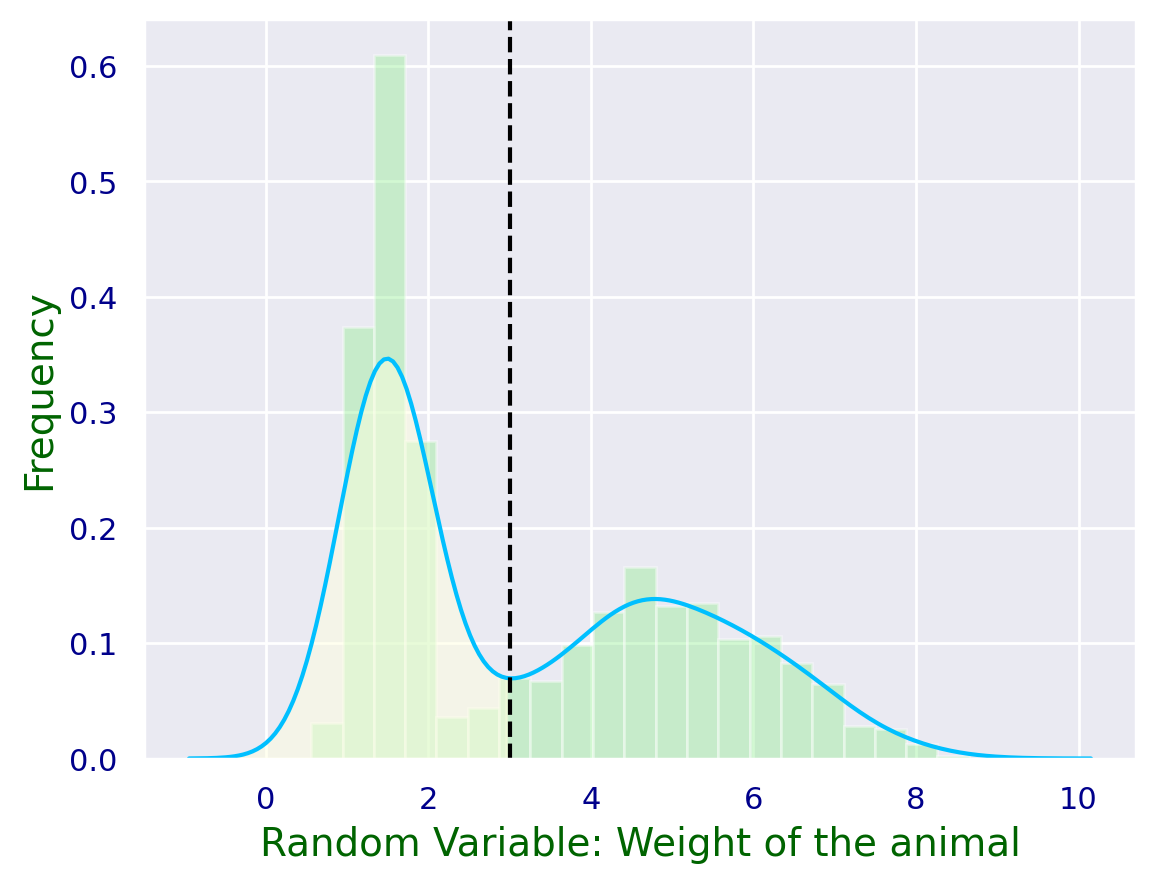

In [5]:
plt.figure()
# here we simualte two populations: squirrels and rabbits
data_weights = np.concatenate([norm.rvs(size=500,loc=1.5,scale=0.3),norm.rvs(size=500,loc=5,scale=1.25)],axis=0)
data_weights = np.round(data_weights,2)
animal = np.repeat([0,1],500)
# then we want to display the histogram and the fit of the underlying distribution:
ax1 = sns.distplot(data_weights,
                  bins=21,
                  kde=True,
                  color='deepskyblue',
                  hist_kws={"color":'lightgreen'},
                  #fit=stats.norm,
                  #fit_kws={"color":'deepskyblue'}
                   )
ax1.set_xlabel('Random Variable: Weight of the animal',fontsize=14,color='darkgreen')
ax1.set_ylabel('Frequency',fontsize=14,color='darkgreen')
l1 = ax1.lines[0]
plt.axvline(x=3.0, color='black',linestyle='dashed')

x = l1.get_xydata()[:,0]
y = l1.get_xydata()[:,1]
plt.tick_params(axis='x', colors='darkblue')
plt.tick_params(axis='y', colors='darkblue')
ax1.fill_between(x,y, where = x <= 3.0, color='lightyellow',alpha=0.5)

### <font color='navy' size=6pt> Logistic Regression </font>

$$\large
\text{P}(y_i=\text{rabbit}|\text{weight}=x_i) = \frac{1}{1+e^{-\beta_0-\beta_1 x_i}}
$$

the above function is called the "Logistic Sigmoid" (ref. Thomas Malthus)




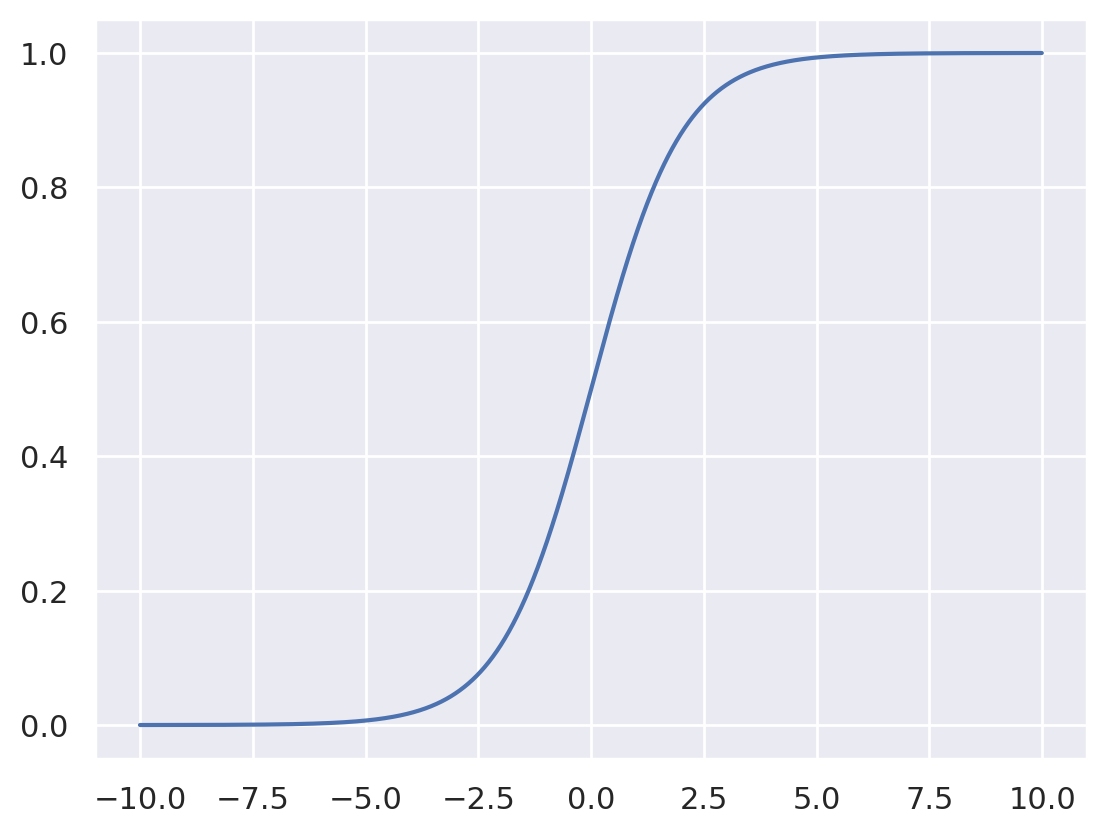

In [6]:
x = np.arange(-10,10,0.01)
y = 1/(1+np.exp(-x)) # this is the logistic sigmoid function
plt.plot(x,y)
plt.show()

In [7]:
data = pd.DataFrame(data=np.column_stack([data_weights,animal]),columns=['weight of animal','animal'])

In [8]:
data.head(3)

,weight of animal,animal
0,1.90,0.0
1,1.89,0.0
2,1.24,0.0


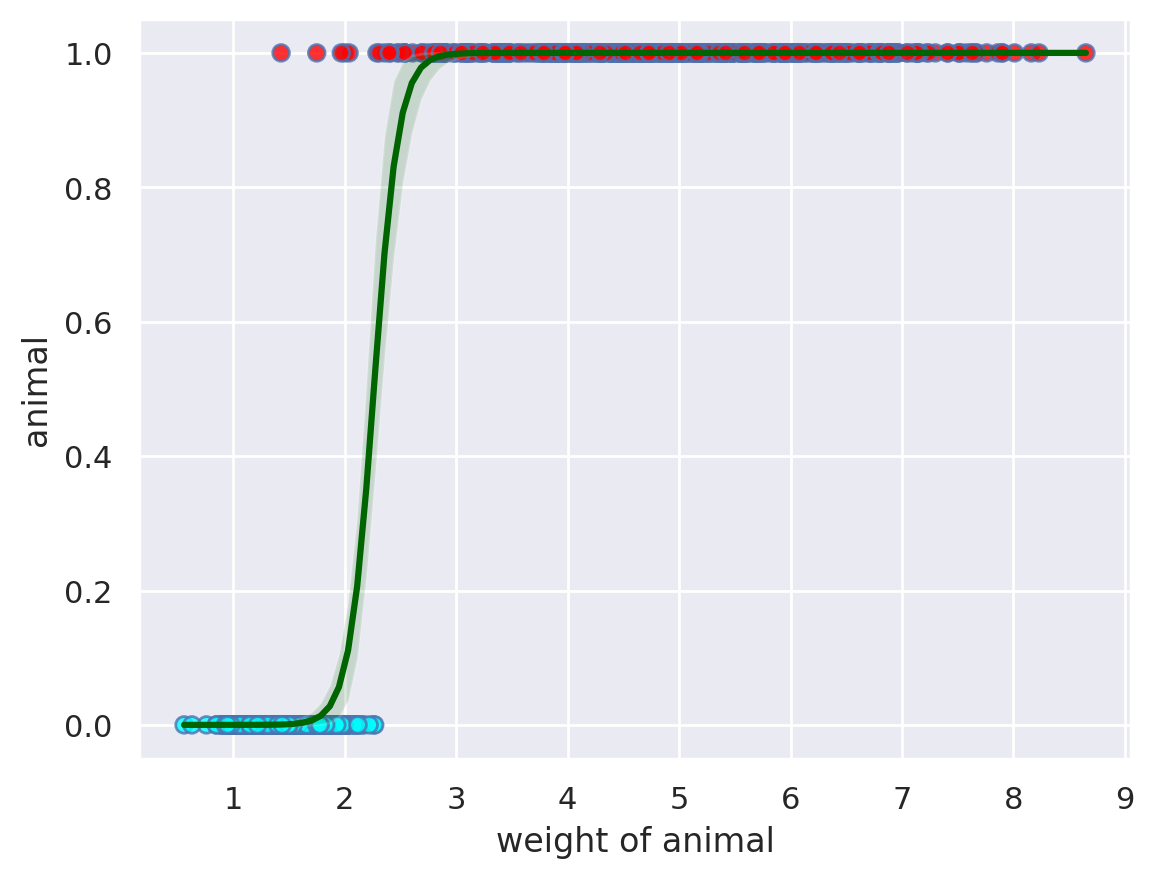

In [9]:
np.seterr(divide='ignore', invalid='ignore')

sns.regplot(x='weight of animal',y='animal',data=data, logistic=True,line_kws={'color': 'darkgreen'},scatter_kws={'facecolors':np.where( animal==0 , 'cyan', 'red')})
plt.show()

## <font color='navy' size=6px> 2D Example with 2 input features - Decision Boundary </font>

The separation of the classes can be visualized in 2D.

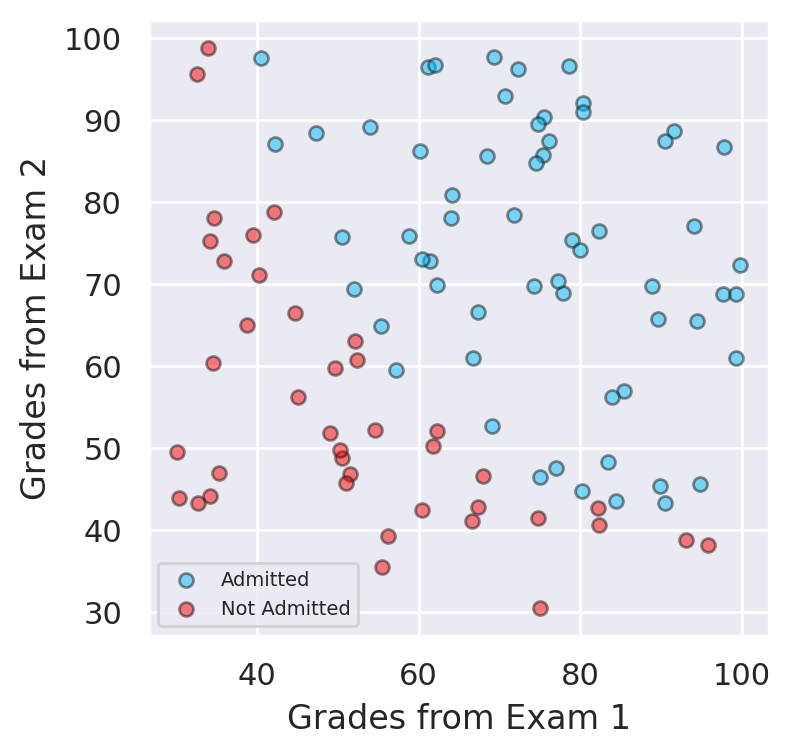

In [10]:
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, confusion_matrix as CM


# function definitions
def load_data(path, header):
    marks_df = pd.read_csv(path, header=header)
    return marks_df

data = pd.read_csv('https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/example_data_classification.csv?raw=true', header=None)

# X = feature values, all the columns except the last column
x = data.iloc[:, :-1]

# y = target values, last column of the data frame
y = data.iloc[:, -1]

# filter out the applicants that got admitted
admitted = data.loc[y == 1]

# filter out the applicants that din't get admission
not_admitted = data.loc[y == 0]

# plots
plt.figure(figsize=(4,4))
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color='red', s=25, ec='k',alpha=0.5,label='Not Admitted')
plt.xlabel("Grades from Exam 1")
plt.ylabel("Grades from Exam 2")
plt.legend(fontsize=7)
plt.show()

In [11]:
y

,2
0,0
1,0
2,0
3,1
4,1
...,...
95,1
96,1
97,1
98,1


### straight line decision boundary

$$\large c_1\cdot E_1 + c_2\cdot E_2 + c_0 = 0 $$

This represents a straight line in feature space.

In [11]:
# we fit a Logistic Regression model
model = LogisticRegression(solver='lbfgs')
model.fit(x, y)
predicted_classes = model.predict(x)
# For now we display training accuracy to understand model behavior.
# Later we will evaluate generalization using validation/test data and cross-validation.
accuracy = accuracy_score(y,predicted_classes)
print(model.coef_)
print(model.intercept_)
print(accuracy)

[[0.20535491 0.2005838 ]]
[-25.05219314]
0.89


In [12]:
# Let's assume some new input data
E1 = 84
E2 = 24
l = -25.05219314 + 0.20535491*E1 +0.2005838*E2

In [13]:
l

-2.9883695

In [14]:
# now to compute the probability we use the logistic sigmoid function
1/(1+np.exp(-l))

np.float64(0.04795407463918614)

In [15]:
model.predict_proba([[84,24]])

array([[0.95204591, 0.04795409]])

If we only want to predict probabilities, then in this particular example we have:

$$l\overset{\Delta}{=}c_0+c_1\cdot E_1 + c_2\cdot E_2$$

and the probability of admission is calculated as follows:

$$\large p=\frac{1}{1+e^{-l}}$$

### Visualize the Decision Boundary

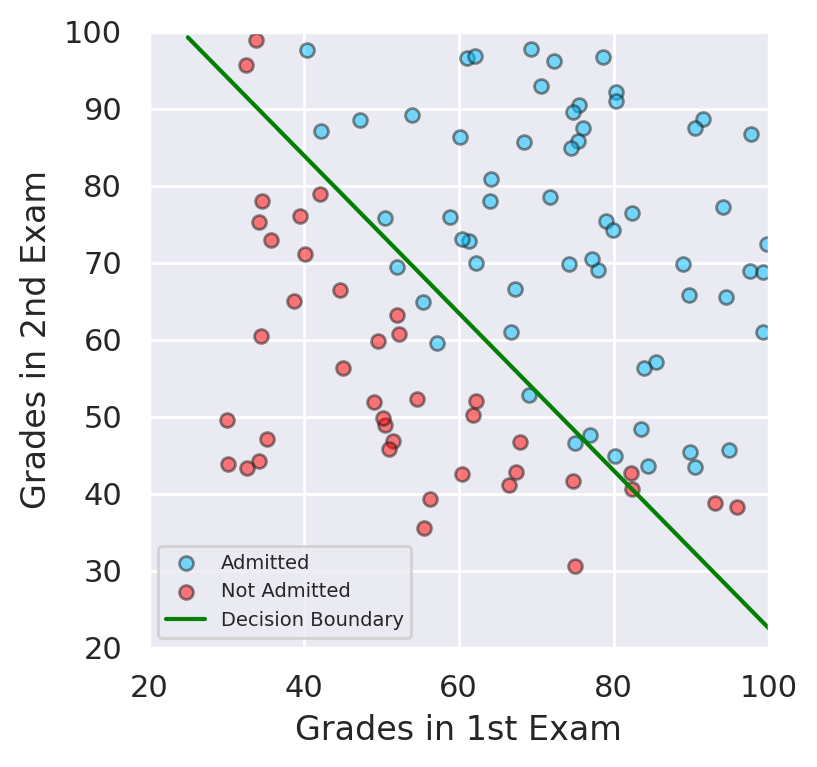

In [16]:
# Here we visualize hte decision boundary
# E1_values mean grades from Exam 1 and E2_values mean grades from Exam 2
E1_values = [np.min(x.values[:, 0] - 5), np.max(x.values[:, 0] + 5)]
E2_values = - (model.intercept_ + model.coef_[:,0]*E1_values) / model.coef_[:,1] # the decision boundary equation

# plots
plt.figure(figsize=(4,4))
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color='red', s=25, ec='k',alpha=0.5,label='Not Admitted')
plt.plot(E1_values, E2_values, label='Decision Boundary',color='green')
plt.xlim(20,100)
plt.ylim(20,100)
plt.xlabel('Grades in 1st Exam')
plt.ylabel('Grades in 2nd Exam')
plt.legend(fontsize=7)
plt.show()

In [17]:
# We want to predict for a new student the probability of admission:
model.predict_proba([[38,92]]) # this student was admitted

array([[0.23058632, 0.76941368]])

In [18]:
p=model.predict_proba([[82,45]])

In [21]:
# The probability that the student was not admitted
print('The probability that the student was not admitted (according to logistic regression) is : ' +str(100*p[:,0][0]) + '%')

The probability that the student was not admitted (according to logistic regression) is : 30.72130937437514%


In [22]:
# The probability the student was admitted
p[:,1]

array([0.69278691])

In [23]:
sum(p[0,:])

np.float64(1.0)

## K-Nearest Neighbors Algorithm
#### <font color='red'> Big Idea: The proximity is very important.</font>

<font color='blue'> The classification is decided by the votes of the $k$-nearest neighbors; if $k$ is an odd natural number such as $2p+1$ then we know the vote is not a tie.

<font color='forestgreen'> The votes can be weighted (if we want) by the inverse of the Euclidean distance.</font>



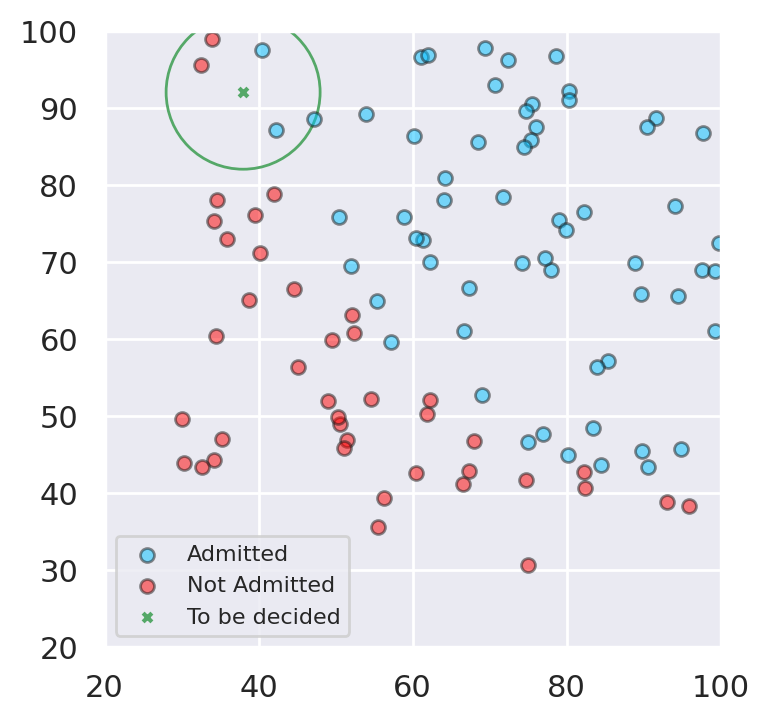

In [19]:
from IPython.core.pylabtools import figsize

fig, ax = plt.subplots(figsize=(4,4))

circle = plt.Circle((38, 92), 10, color='g', fill=False)

ax = plt.gca()
ax.cla() # clear things for fresh plot

# change default range so that new circles will work
ax.set_xlim((20, 100))
ax.set_ylim((20, 100))
# some data
ax.plot(range(11), 'o', color='black')
# key data point that we are encircling
ax.plot((5), (5), 'o', color='y')
ax.add_artist(circle)

ax.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
ax.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color='red', s=25, ec='k',alpha=0.5,label='Not Admitted')
ax.scatter(38,92, s=10,marker='x',color='g',label='To be decided')
ax.set_aspect('equal', 'box')
plt.legend(fontsize=8)
#fig.savefig('plotcircles2.png')
plt.show()

In [20]:
n_neighbors = 5
h = .1 # step size in the grid of points
cmap_light = ListedColormap(['bisque', 'lightcyan'])
cmap_bold = ListedColormap(['red', '#00FF00'])

In [21]:
# setup import KNN classifier from SKlearn
from sklearn import neighbors

Accuracy : 0.95
Accuracy : 1.0


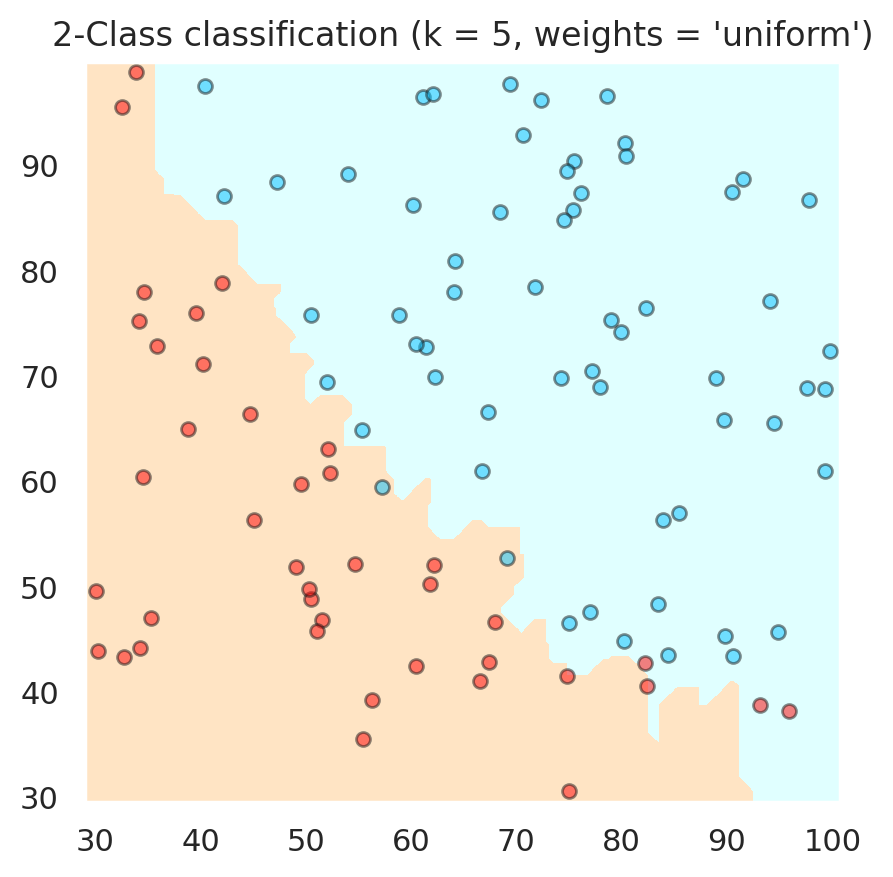

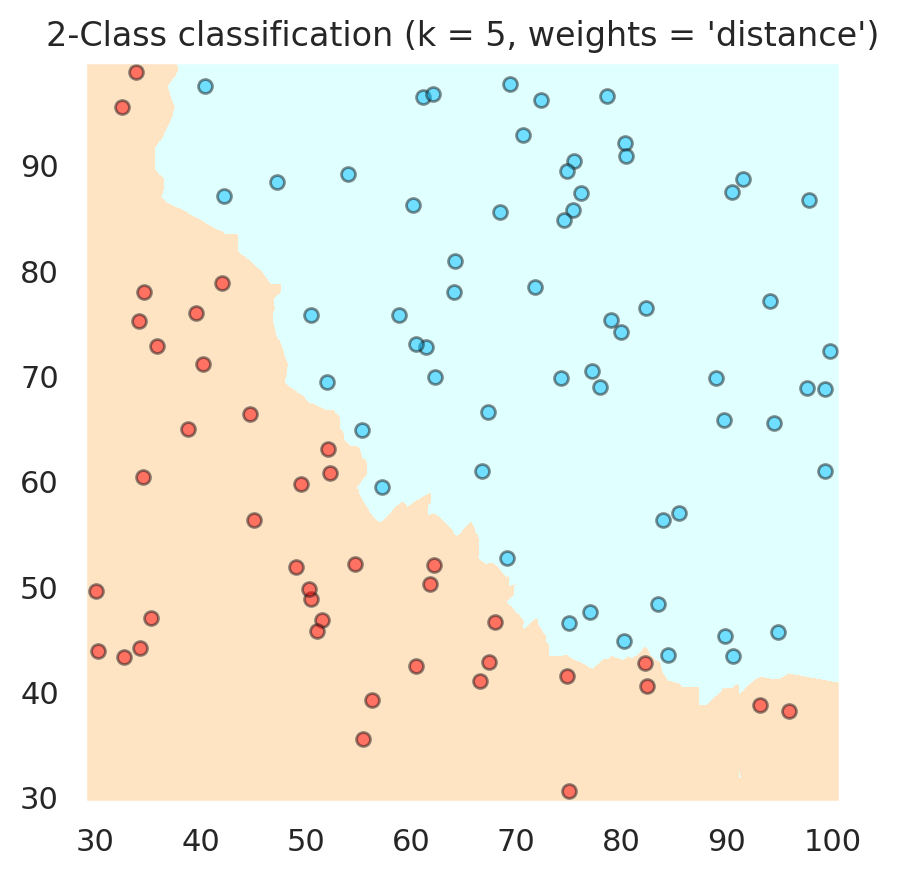

In [22]:
for weights in ['uniform', 'distance']:
    # we create an instance of Neighbours Classifier and fit the data.
    # p=1 → Manhattan distance; p=2 → Euclidean distance
    clf = neighbors.KNeighborsClassifier(n_neighbors, weights=weights,p=1)
    clf.fit(x, y)

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = x.values[:, 0].min() - 1, x.values[:, 0].max() + 1
    y_min, y_max = x.values[:, 1].min() - 1, x.values[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    fig, ax = plt.subplots()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot also the points
    plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1], color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
    plt.scatter(not_admitted.iloc[:, 0] ,not_admitted.iloc[:, 1], color ='red', s=25,ec='k',alpha=0.5, label='Not Admitted')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    ax.set_aspect('equal', 'box')
    plt.title("2-Class classification (k = %i, weights = '%s')"
              % (n_neighbors, weights))
    print('Accuracy : ' + str(accuracy_score(y,clf.predict(x))))

plt.show()

## Decision Tree classifier

In [23]:
from sklearn import tree
model = tree.DecisionTreeClassifier(random_state=123, max_depth=5)
model.fit(x, y);
predicted_classes = model.predict(x)
accuracy = accuracy_score(y,predicted_classes)
print(accuracy)

1.0


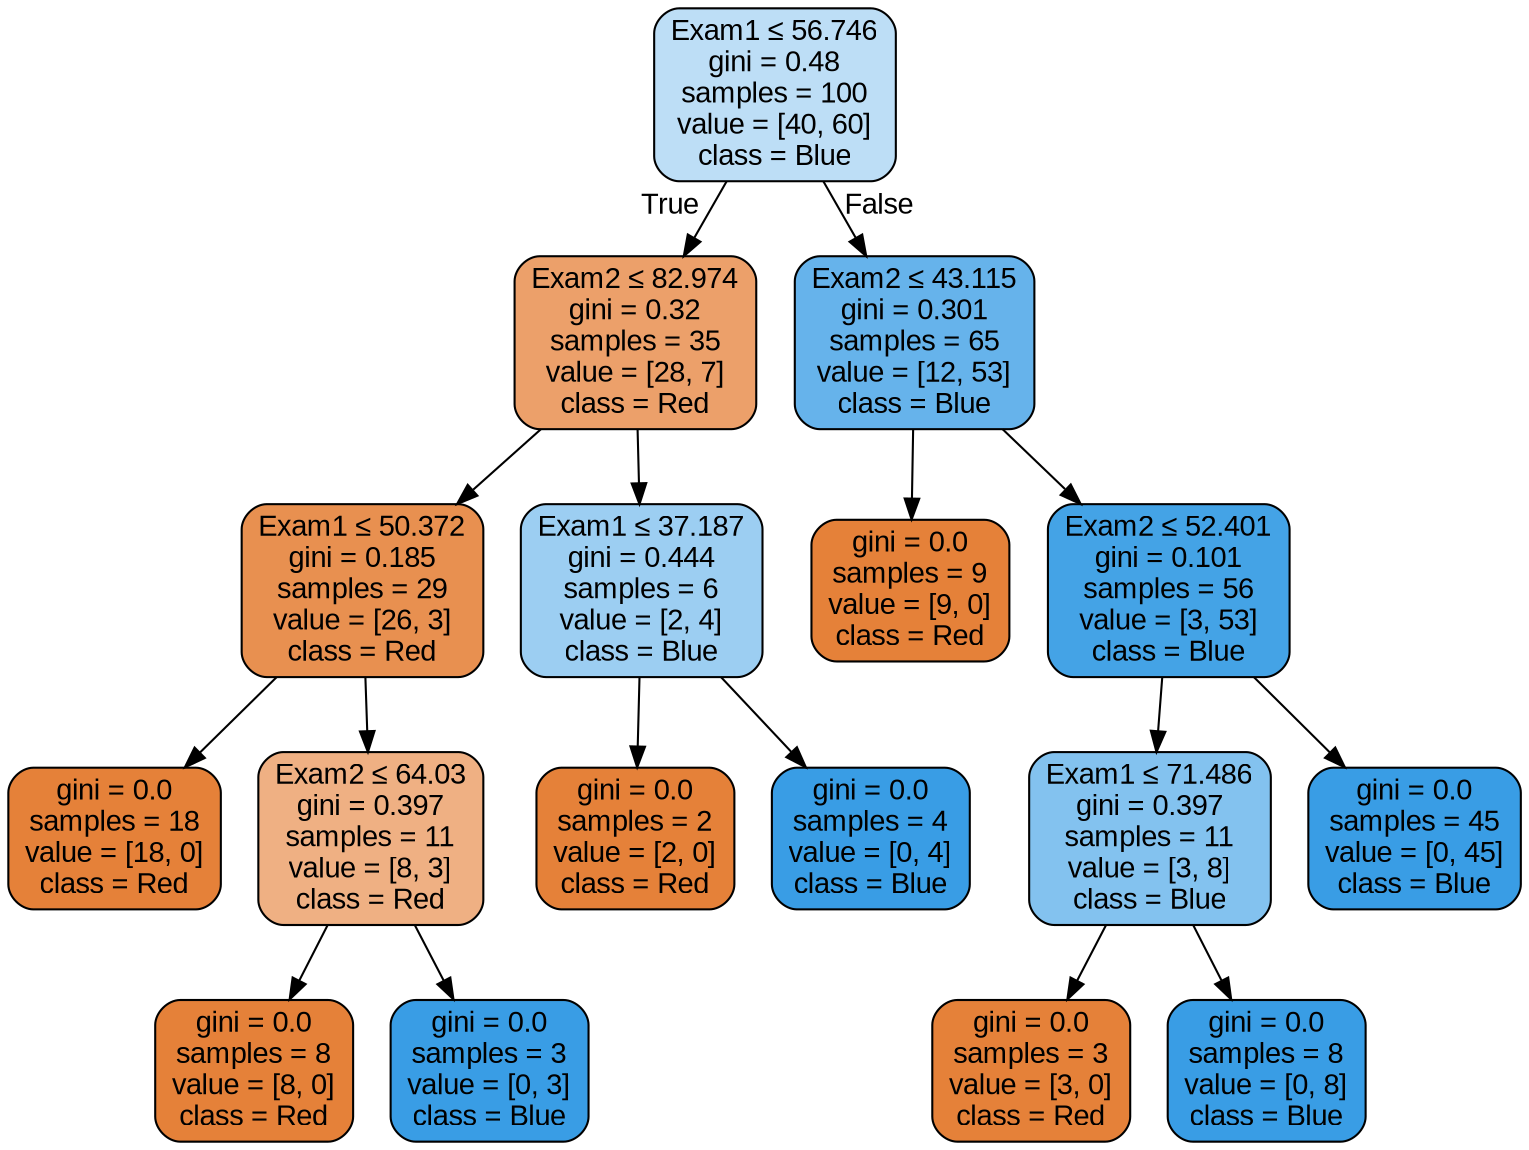

In [24]:
import pydot
from IPython.display import Image


feats = ['Exam1','Exam2']
spc = ['Red','Blue']

def ShowTree(classifier, features, classes):
    dot_data = tree.export_graphviz(classifier, out_file=None, filled=True, rounded=True,
                special_characters=True, feature_names=features, class_names=classes)
    (g,) = pydot.graph_from_dot_data(dot_data)
    g.del_node('"\\n"')
    g.set_dpi('150')
    g.write_png('tree.png')
    return Image(g.create_png())


ShowTree(model, feats, spc)

In [27]:
for depth in [1, 2, 3, 5, 7, None]:
    model = tree.DecisionTreeClassifier(
        max_depth=depth,
        random_state=123
    )
    model.fit(x, y)

    print(
        f"max_depth={depth}: "
        f"training accuracy={model.score(x,y):.3f}"
    )

max_depth=1: training accuracy=0.810
max_depth=2: training accuracy=0.920
max_depth=3: training accuracy=0.940
max_depth=5: training accuracy=1.000
max_depth=7: training accuracy=1.000
max_depth=None: training accuracy=1.000


Does higher training accuracy necessarily mean a better model?

### Gini Impurity Index

$$\large \text{gini} = \displaystyle\sum_{i=1}^{2} p_i\cdot(1-p_i)$$

In [ ]:
p1 = 28/35
p2 = 7/35

In [ ]:
p1*(1-p1)+p2*(1-p2)

0.32

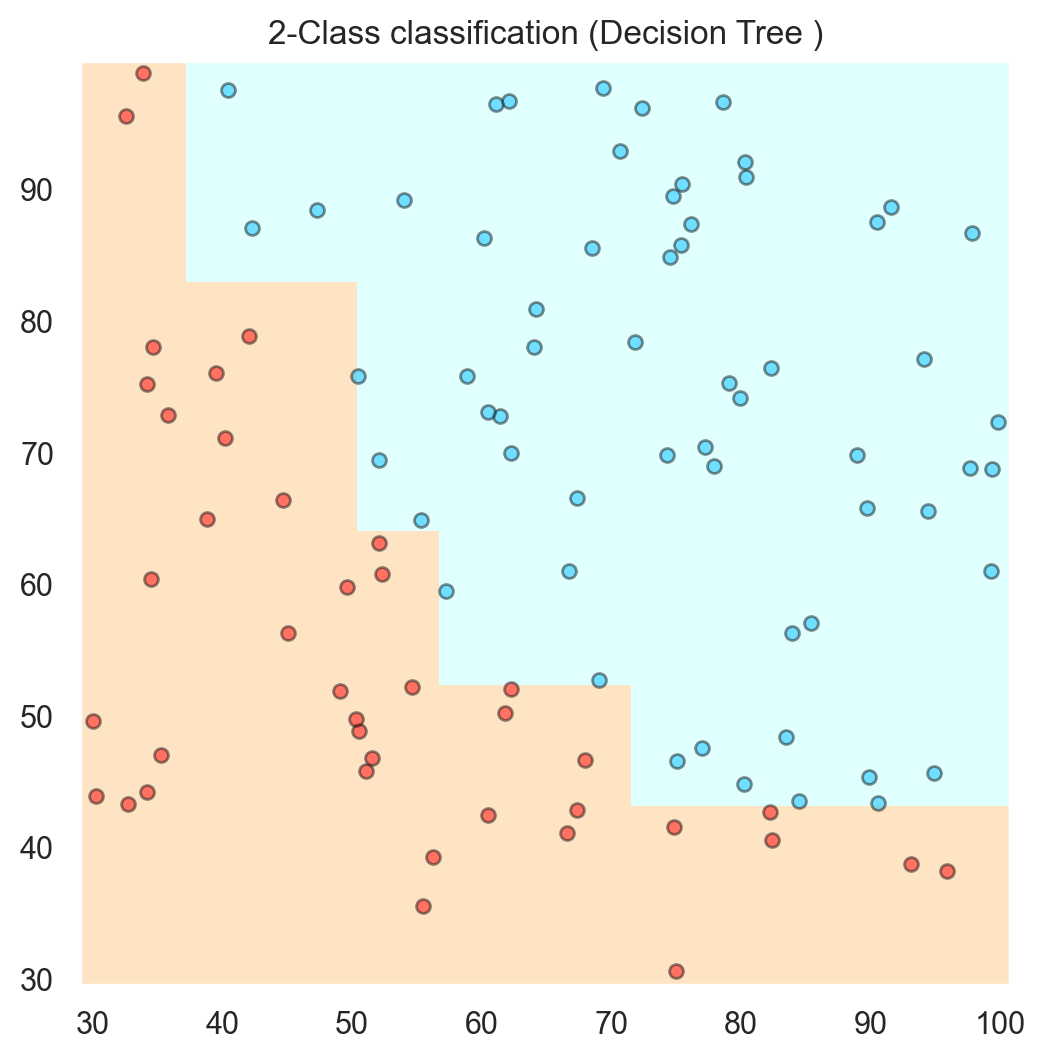

In [ ]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
fig, ax = plt.subplots(figsize=(6,6))
ax.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the points
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],  color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color ='red', s=25,ec='k',alpha=0.5, label='Not Admitted')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("2-Class classification (Decision Tree )")

plt.show()

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=123, max_depth=4, n_estimators = 200)
model.fit(x, y);
predicted_classes = model.predict(x)
accuracy = accuracy_score(y,predicted_classes)
print(accuracy)

1.0


The Random Forest uses many decision trees built with random subsets of the train data. The random sunsets are obtained by sampleing with repetition from the train data; this is called "bagging".

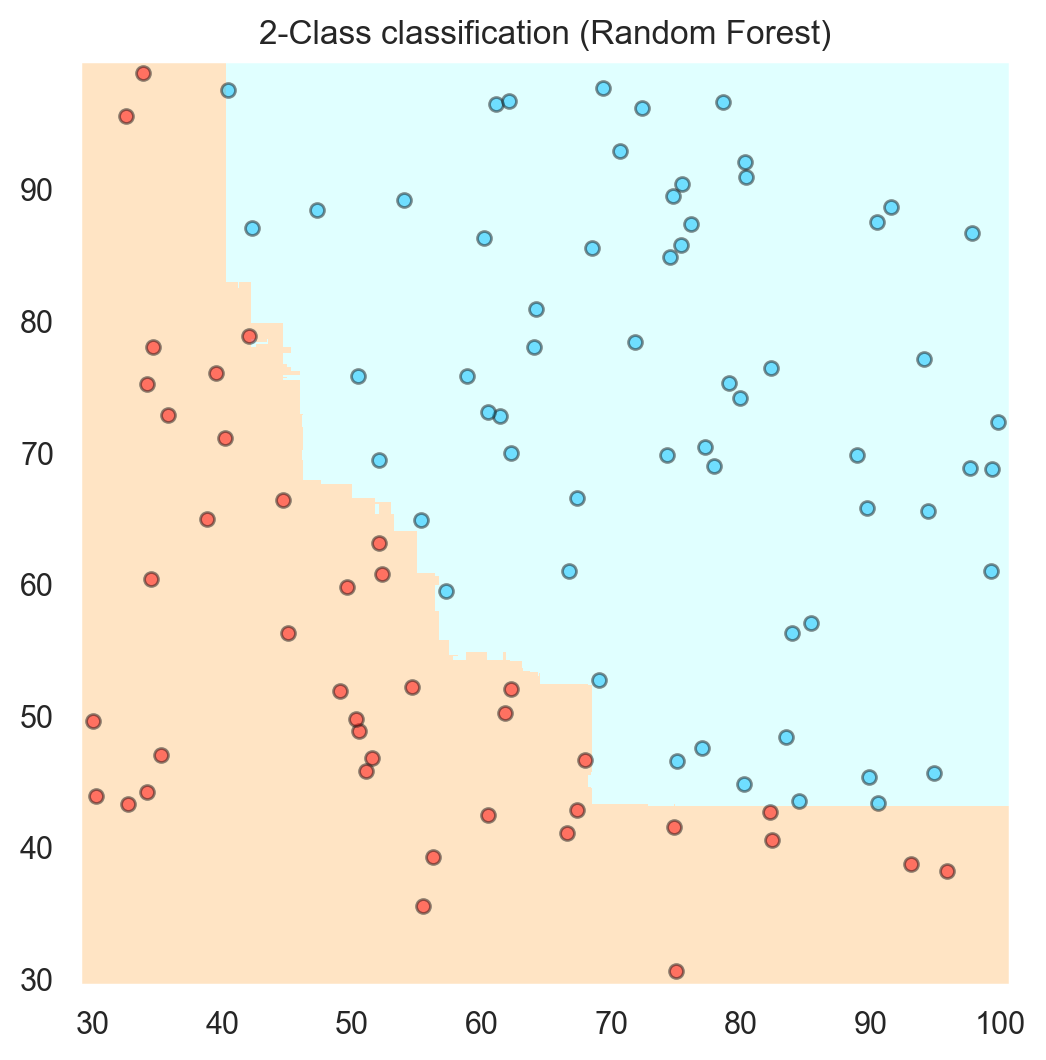

In [ ]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
fig, ax = plt.subplots(figsize=(6,6))
ax.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the points
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],  color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color ='red', s=25,ec='k',alpha=0.5, label='Not Admitted')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("2-Class classification (Random Forest)")

plt.show()

## Applications with Metrics for Classification

### Simulation Study with Weights from two Animals: Squirrels and Rabbitts

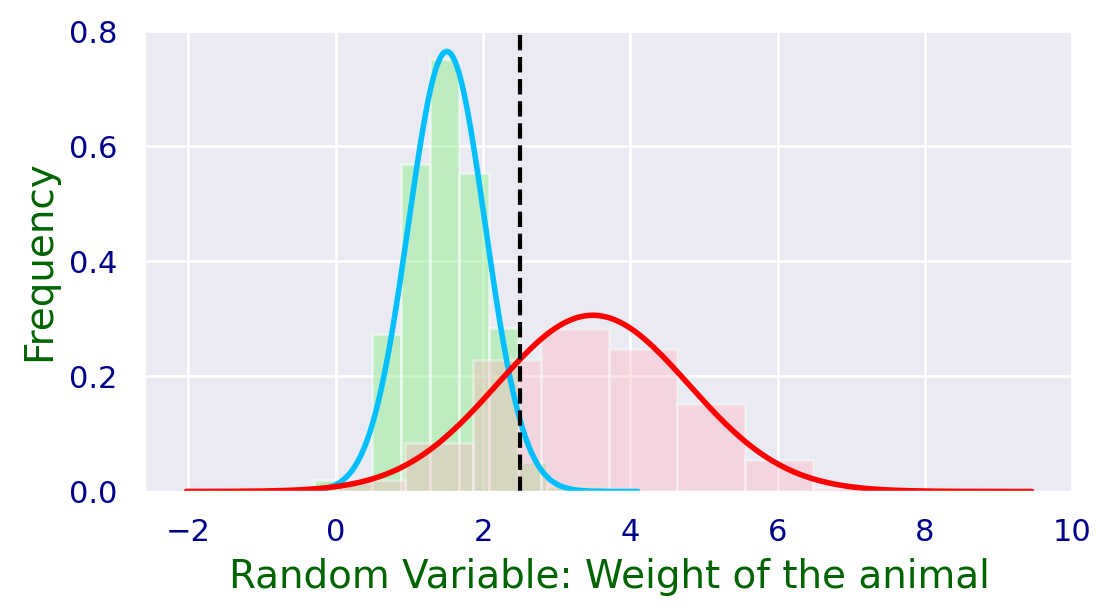

<Figure size 500x500 with 0 Axes>

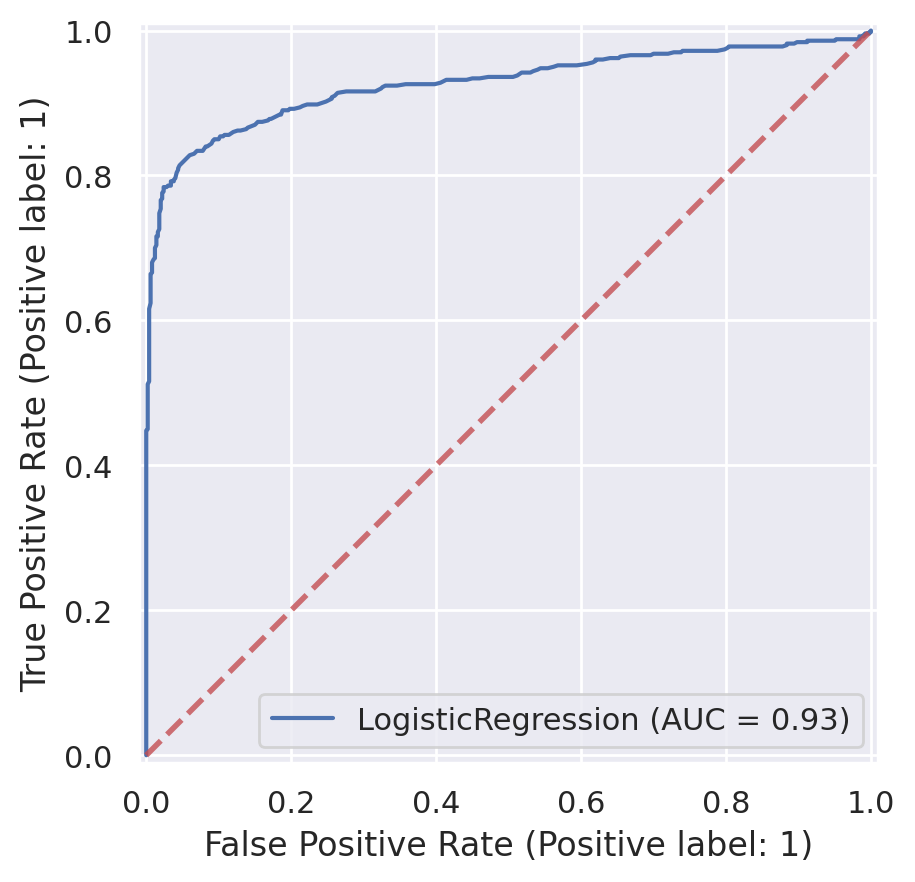

NameError: name 'svm' is not defined

In [28]:
plt.figure(figsize=(6,3))
animal_weights = np.concatenate([norm.rvs(size=500,loc=1.5,scale=0.5),norm.rvs(size=500,loc=3.5,scale=1.25)],axis=0)
animal_weights = np.round(animal_weights,2)
outcome = np.repeat([0,1],[500,500])
# then we want to display the histogram and the fit of the underlying distribution:
ax1 = sns.distplot(animal_weights[:500],
                  bins=10,
                  kde=False,
                  color='deepskyblue',
                  hist_kws={"color":'lightgreen','alpha':0.5},
                  fit=stats.norm,
                  fit_kws={"color":'deepskyblue','lw':2}
                   )
ax1 = sns.distplot(animal_weights[500:-1],
                  bins=10,
                  kde=False,
                  color='red',
                  hist_kws={"color":'lightpink'},
                  fit=stats.norm,
                  fit_kws={"color":'red','lw':2}
                   )
ax1.set_xlabel('Random Variable: Weight of the animal',fontsize=14,color='darkgreen')
ax1.set_ylabel('Frequency',fontsize=14,color='darkgreen')
l1 = ax1.lines[0]
plt.axvline(x=2.5, color='black',linestyle='dashed')

x = l1.get_xydata()[:,0]
y = l1.get_xydata()[:,1]
plt.tick_params(axis='x', colors='darkblue')
plt.tick_params(axis='y', colors='darkblue')
#ax1.fill_between(x,y, where = x <= 3.0, color='palegreen',alpha=0.5)


model = LogisticRegression(solver='lbfgs',max_iter=10000)

model.fit(animal_weights.reshape(-1,1),outcome)

model.predict_proba(animal_weights.reshape(-1,1))

plt.figure(figsize=(5,5))
RocCurveDisplay.from_estimator(model, animal_weights.reshape(-1,1), outcome.reshape(-1,1))
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)
plt.show()

model = svm.SVC(kernel='poly',C=1,degree=5)
model.fit(animal_weights.reshape(-1,1),outcome)

plt.figure(figsize=(5,5))
RocCurveDisplay.from_estimator(model, animal_weights.reshape(-1,1), outcome)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)
plt.show()

### Coding Example for Determining the validated ROC with the Electrical Grid Data

In [ ]:

df = pd.read_csv('https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/ElectricalGridData.csv?raw=true')
x = df.loc[:,'tau1':'g4'].values
labels = LabelEncoder()
y = labels.fit_transform(df['stabf'])

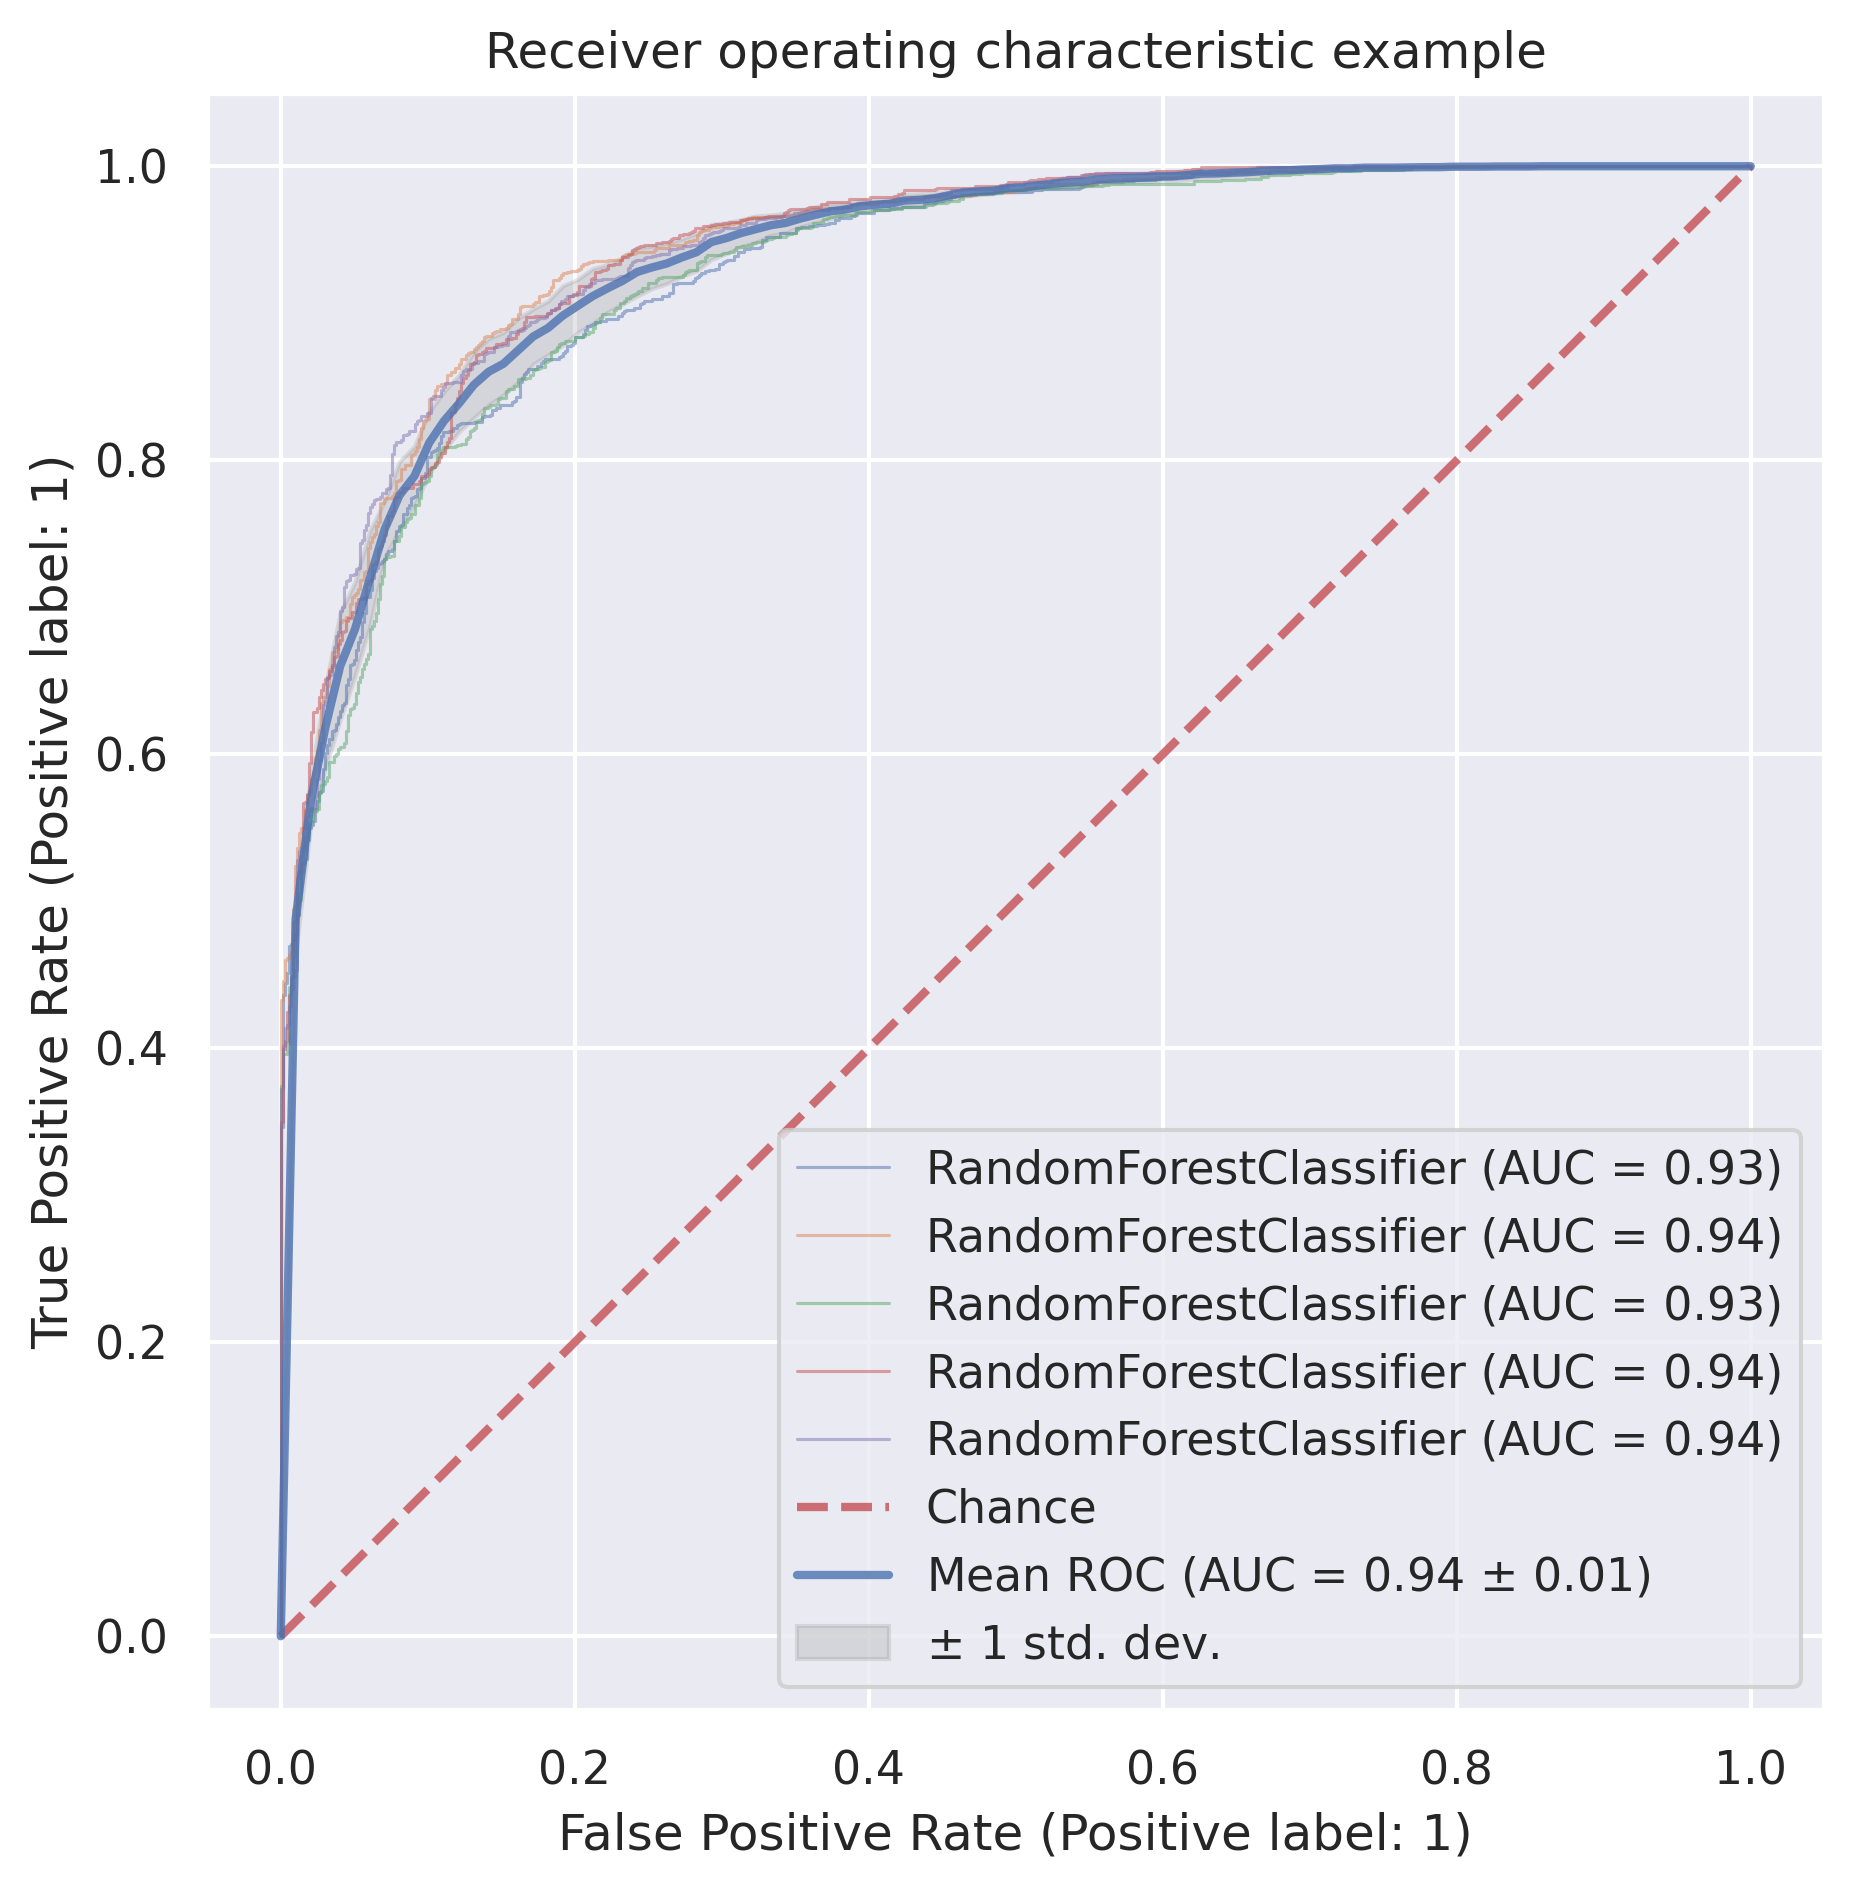

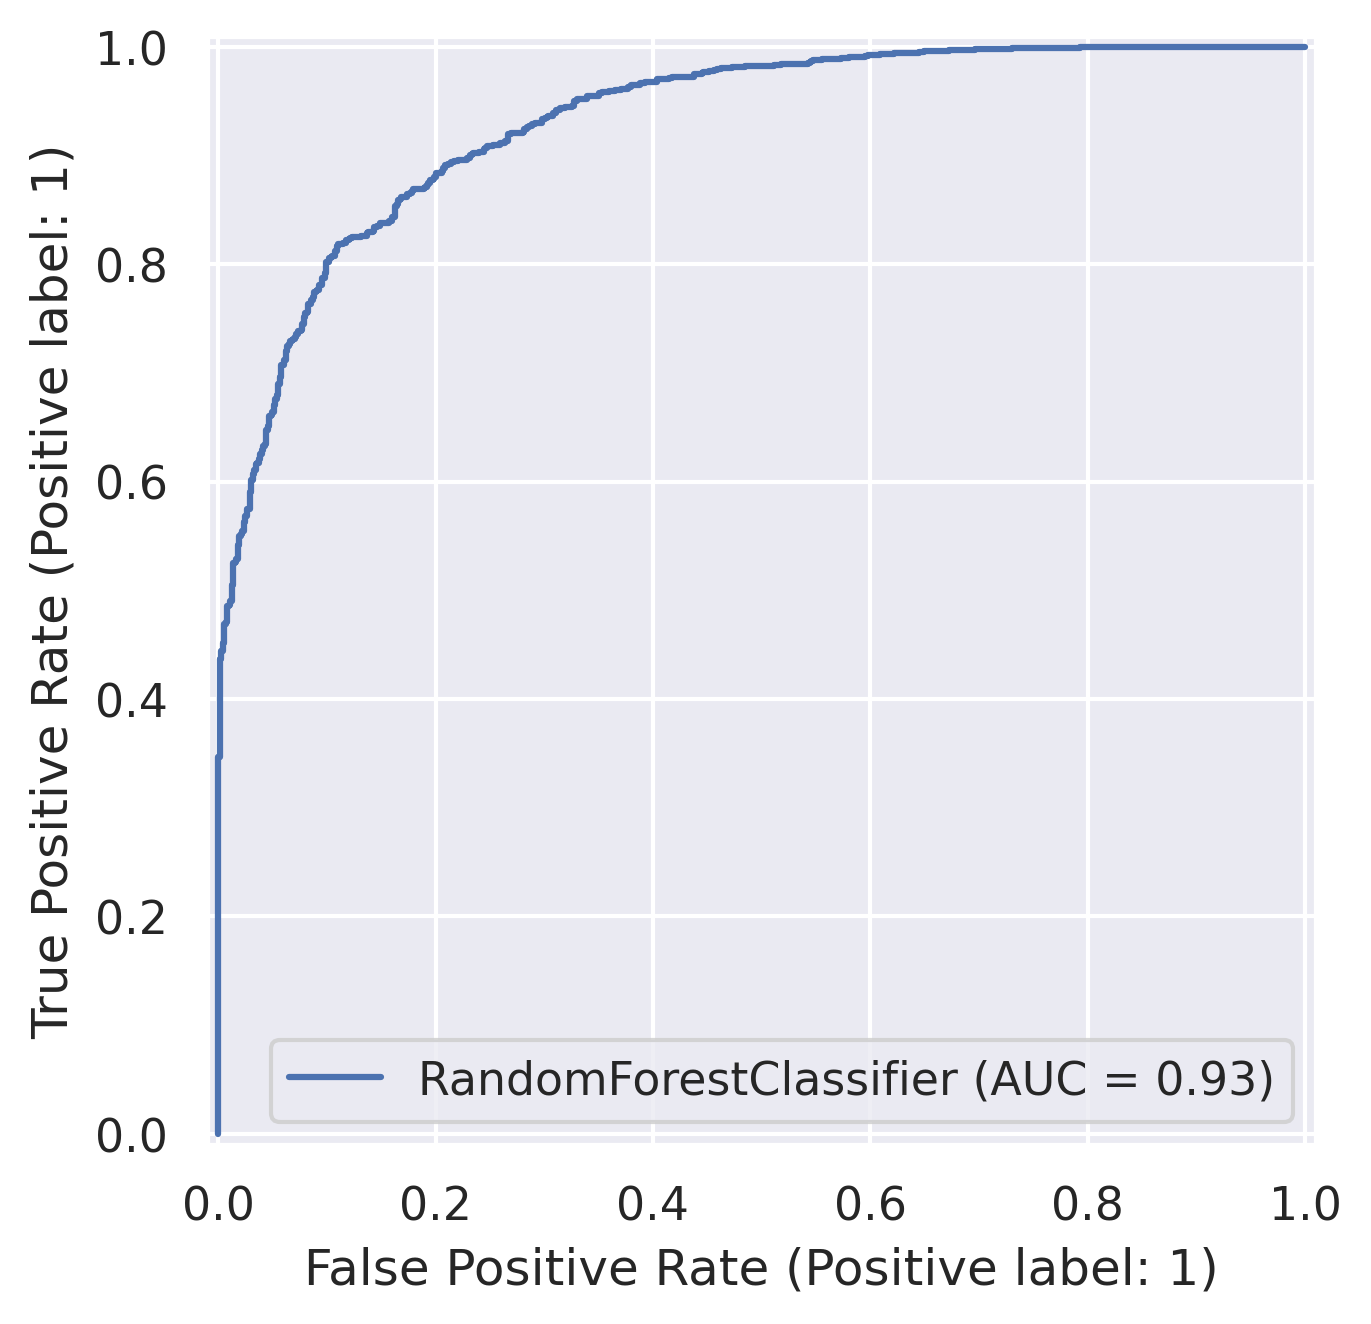

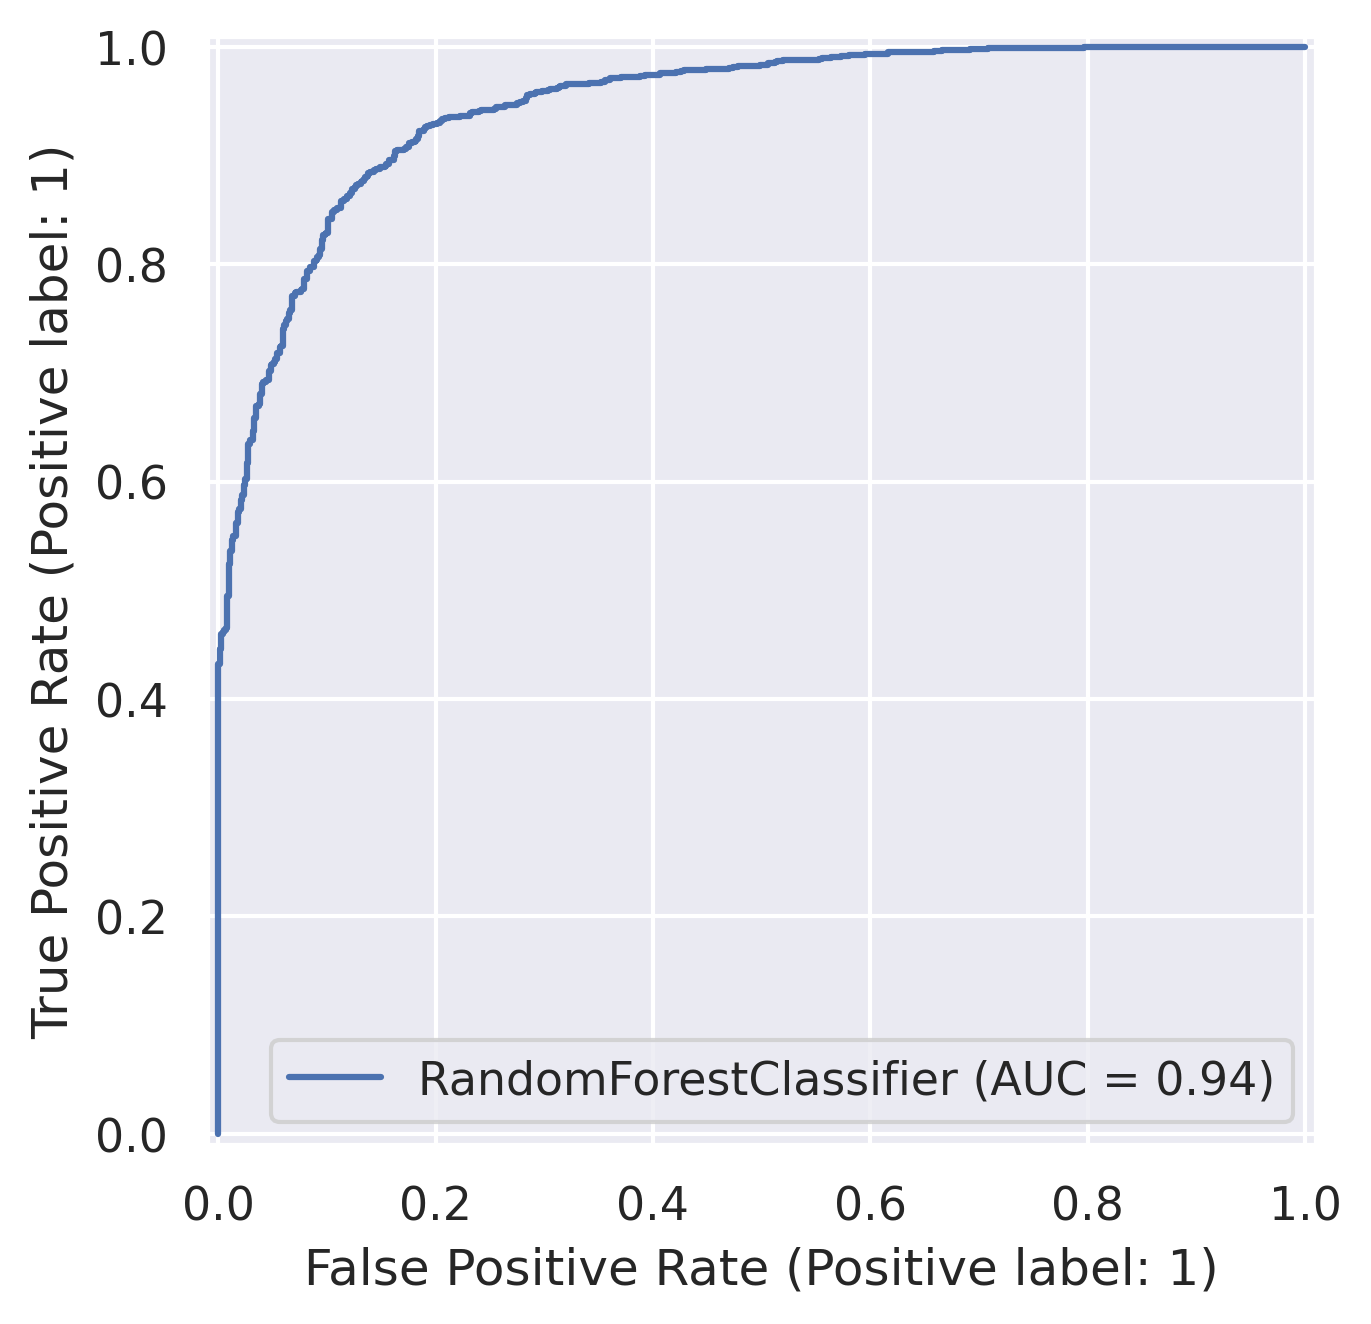

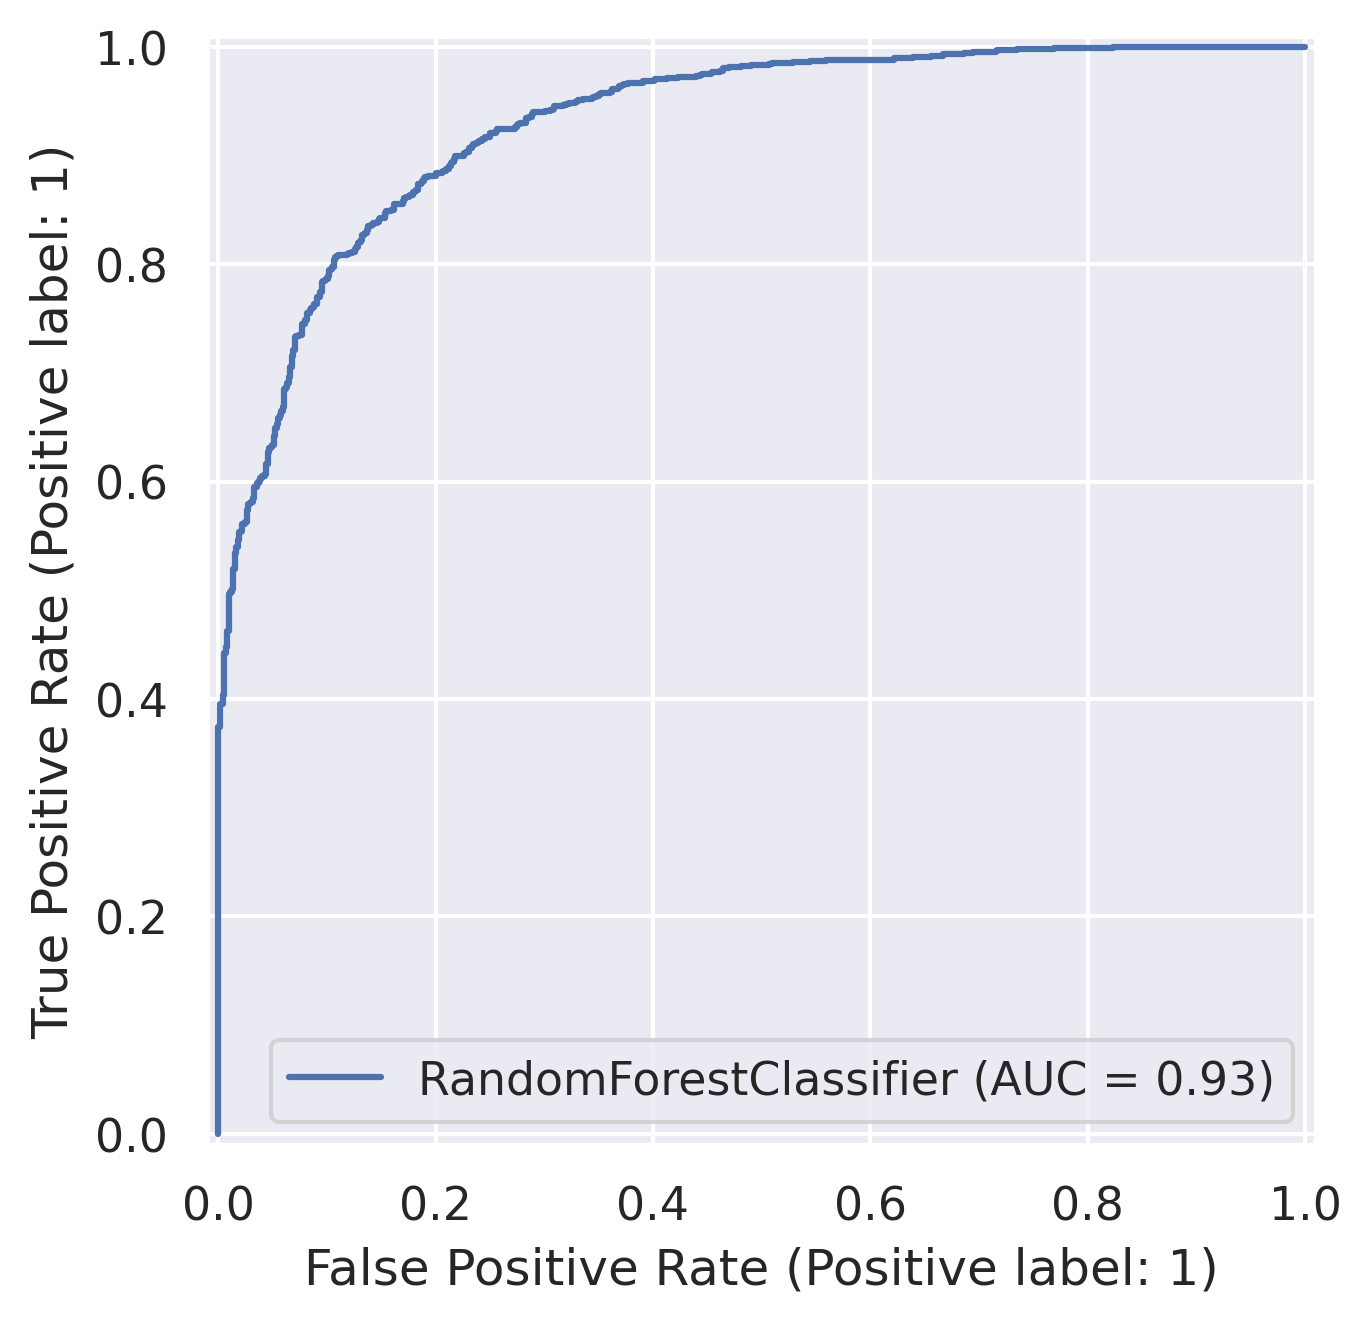

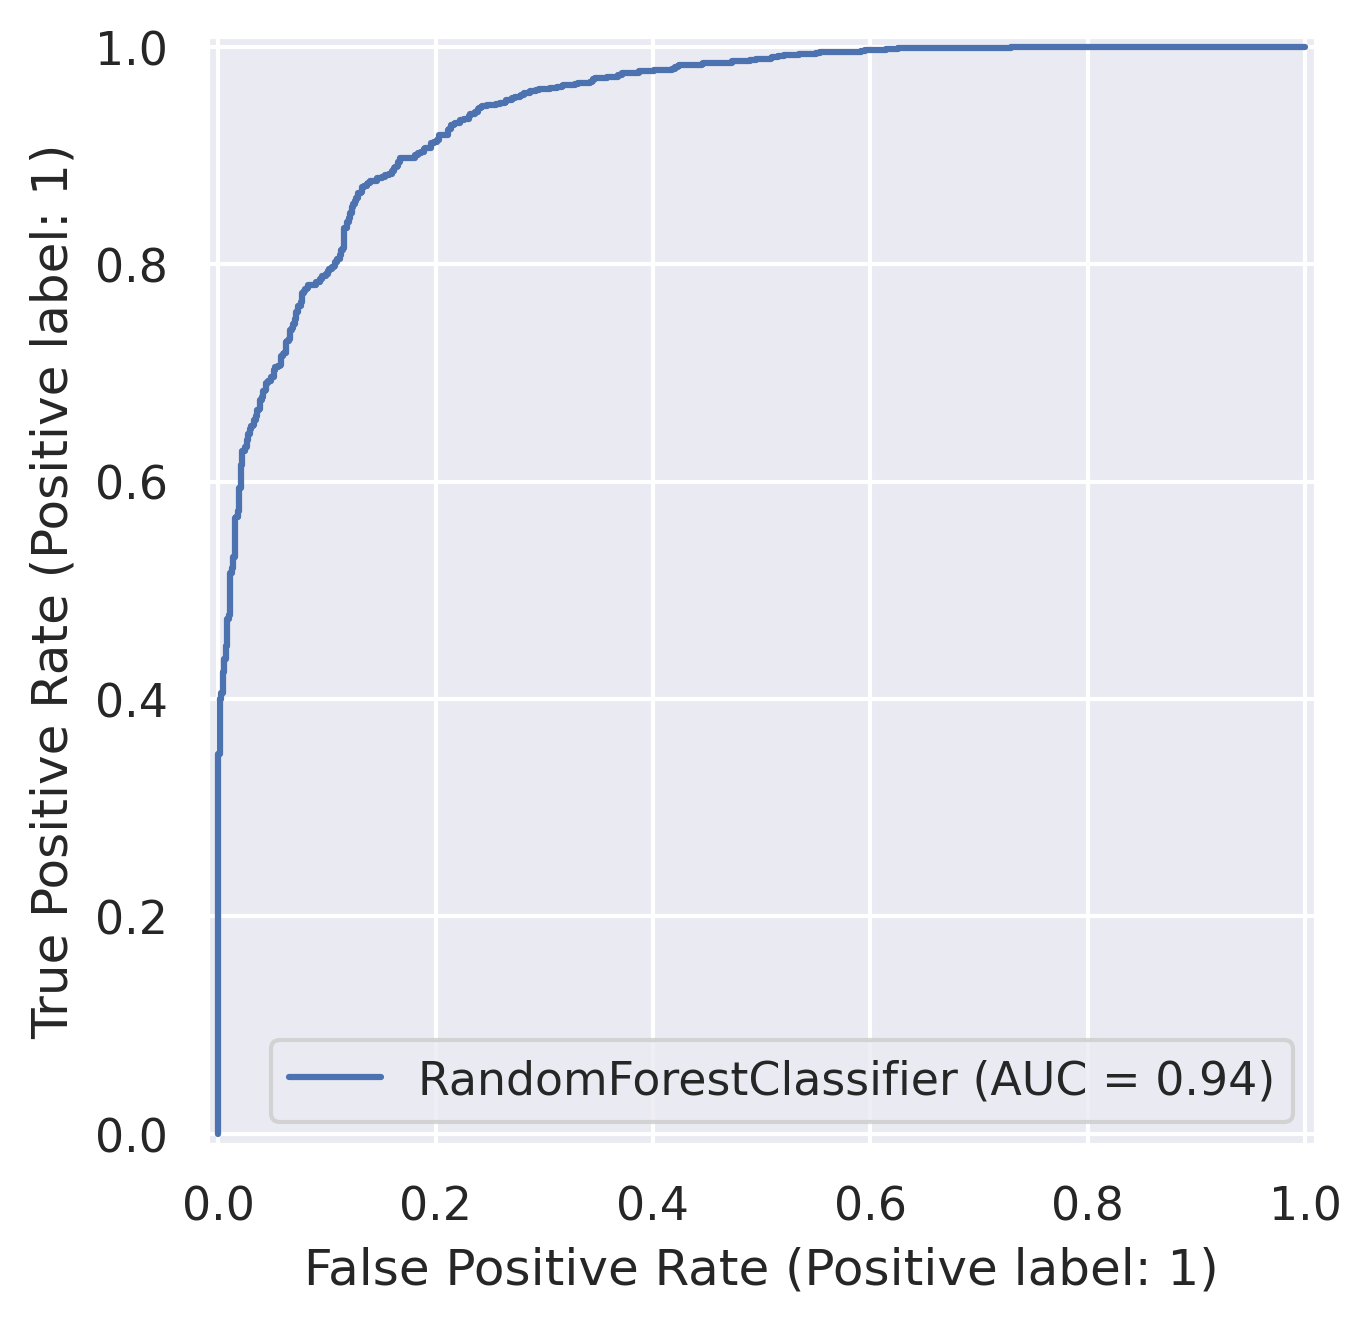

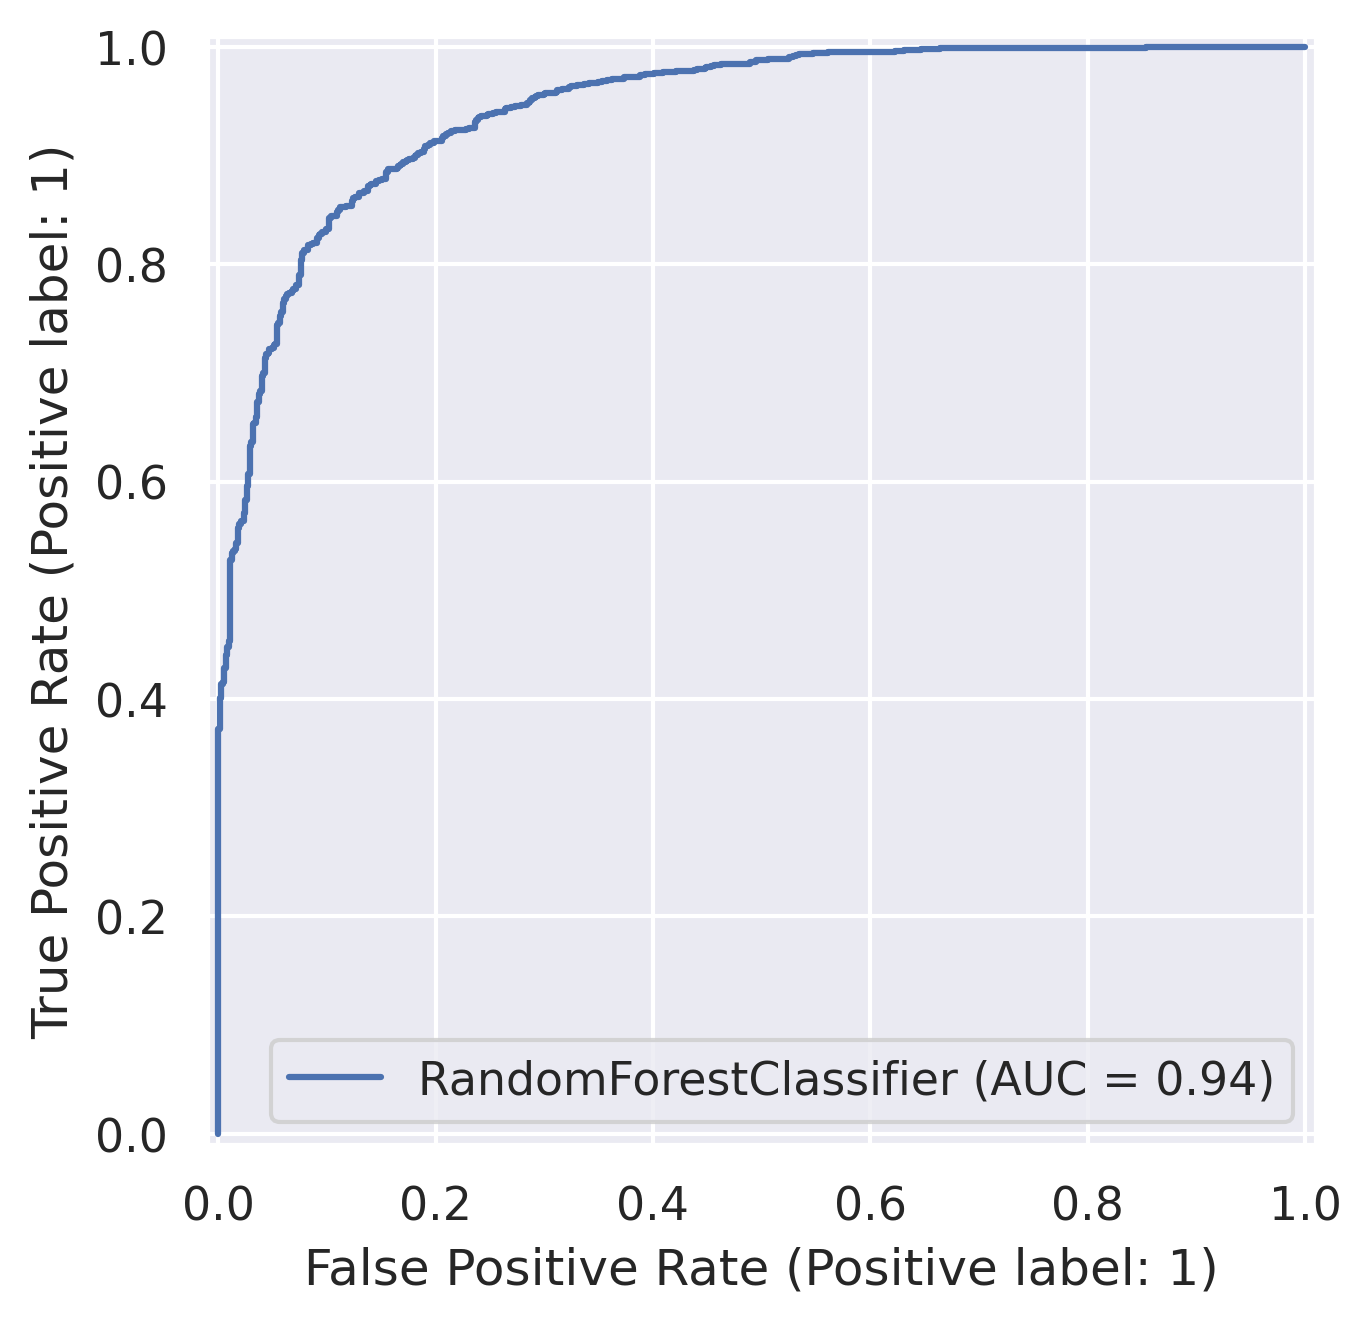

In [ ]:
n_samples, n_features = x.shape


# #############################################################################
# Classification and ROC analysis

# Run classifier with cross-validation and plot ROC curves
cv = StratifiedKFold(n_splits=5,shuffle = True,random_state=301)
#classifier = SVC(kernel='rbf', gamma=0.0001,probability=True,random_state=310)
#classifier = LogisticRegression(solver='lbfgs',max_iter=100000)
classifier = RandomForestClassifier(n_estimators=100,max_depth=4)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig,ax = plt.subplots(figsize=(7,7))
for i, (train, test) in enumerate(cv.split(x, y)):
    classifier.fit(x[train], y[train])
    viz = RocCurveDisplay.from_estimator(classifier, x[test], y[test])
    viz.plot(ax=ax,alpha=0.5,lw=0.75)
    fpr, tpr, thresholds = roc_curve(y[test], classifier.predict_proba(x[test])[:,1])
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Receiver operating characteristic example")
ax.legend(loc="lower right")
plt.show()